# Exploratory Data Analysis - Default of Credit Card Clients
Created by Guillermo Arredondo Renero

Creation date: May 3, 2026  
Last updated: May 3, 2026

**Main objective**: This notebook provides a comprehensive exploratory data analysis of the credit card default dataset. 

**Structure:**
1. Data Overview and Structure
2. Missing Values and Data Quality
3. Univariate Analysis
4. Target Variable Analysis
5. Demographic Analysis
6. Credit Utilization Analysis
7. Payment Behavior Analysis
8. Correlation Analysis
9. Outlier Detection
10. Summary of Key Insights

In [1]:
# ---------------------------- Libraries
## Directories
import os
## Data manipulation
import pandas as pd
import numpy as np

## Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable

# Extras
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
# ---------------------------- Directories
# Get main directory
CURRENT_DIR = os.getcwd()
MAIN_DIR = os.path.dirname(CURRENT_DIR)
DATA_DIR = os.path.join(MAIN_DIR, 'data', 'raw')

## 1. Data Loading and Overview

In [3]:
# Load the dataset
df = pd.read_csv(os.path.join(DATA_DIR, 'credit_dataset.csv'))

original_columns = df.columns.tolist()
# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("First 5 rows:")
print(df.head())
print("\n" + "="*80)
print("Data Types:")
print(df.dtypes)
print("\n" + "="*80)
print("Basic Statistics:")
df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

Dataset Shape: (30000, 24)

First 5 rows:
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  \
0     -2     -2       3913       3102        689          0          0   
1      0      2       2682       1725       2682       3272       3455   
2      0      0      29239      14027      13559      14331      14948   
3      0      0      46990      48233      49291      28314      28959   
4      0      0       8617       5670      35835      20940      19146   

   BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
10%,30000.000000,1.000000,1.000000,1.000000,25.000000,-1.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,278.900000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
90%,360000.000000,2.000000,3.000000,2.000000,49.000000,2.000000,2.000000,2.000000,2.000000,0.000000,2.000000,142133.700000,136905.500000,1.320513e+05,122418.700000,115883.000000,112110.400000,10300.000000,1.040110e+04,10000.00000,9570.600000,9500.000000,9600.000000,1.000000
95%,430000.000000,2.000000,3.000000,2.000000,53.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,201203.050000,194792.200000,1.878210e+05,174333.350000,165794.300000,161912.000000,18428.200000,1.900435e+04,17589.40000,16014.950000,16000.000000,17343.800000,1.000000


**NOTA:** Las distribuciones de algunas variables no coinciden con los valores esperados y reportados en la documentación: 
- EDUCATION (MIN ES 0, MAX ES 6)
- MARRIAGE (MIN ES 0)
- $PAY\_i,\ i = 0, 1,..., 6$ (MIN ES -2 Y MAX ES 8)

**NOTA:** Discontinuidad / incongruencia en nombres de variables - PAY_0, PAY_2, PAY_3... ¿y PAY_1? -> RENOMBRAR PARA SER CONSISTENTE CON BILL_AMT1 Y PAY_AMT1

## 2. Missing Values and Data Quality

In [4]:
# Check missing values
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values detected")
df.stb.missing().query('missing > 0')

Missing Values:
No missing values detected


,missing,total,percent


In [5]:
# Check for duplicate rows
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


Duplicate Rows: 35


En teoría no debería haber duplicados al tratarse de IDs de clientes, por lo que son duplicados por casualidad. 

In [6]:
# Display column information
print("\nColumn Information:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}, Unique values: {df[col].nunique()}")


Column Information:
LIMIT_BAL: int64, Unique values: 81
SEX: int64, Unique values: 2
EDUCATION: int64, Unique values: 7
MARRIAGE: int64, Unique values: 4
AGE: int64, Unique values: 56
PAY_0: int64, Unique values: 11
PAY_2: int64, Unique values: 11
PAY_3: int64, Unique values: 11
PAY_4: int64, Unique values: 11
PAY_5: int64, Unique values: 10
PAY_6: int64, Unique values: 10
BILL_AMT1: int64, Unique values: 22723
BILL_AMT2: int64, Unique values: 22346
BILL_AMT3: int64, Unique values: 22026
BILL_AMT4: int64, Unique values: 21548
BILL_AMT5: int64, Unique values: 21010
BILL_AMT6: int64, Unique values: 20604
PAY_AMT1: int64, Unique values: 7943
PAY_AMT2: int64, Unique values: 7899
PAY_AMT3: int64, Unique values: 7518
PAY_AMT4: int64, Unique values: 6937
PAY_AMT5: int64, Unique values: 6897
PAY_AMT6: int64, Unique values: 6939
default payment next month: int64, Unique values: 2


## 3. Target Variable Analysis (Default Payment)

Target Variable Distribution:
No Default (0): 23364 clients (77.88%)
Default (1): 6636 clients (22.12%)

Class Imbalance Ratio: 1:3.52


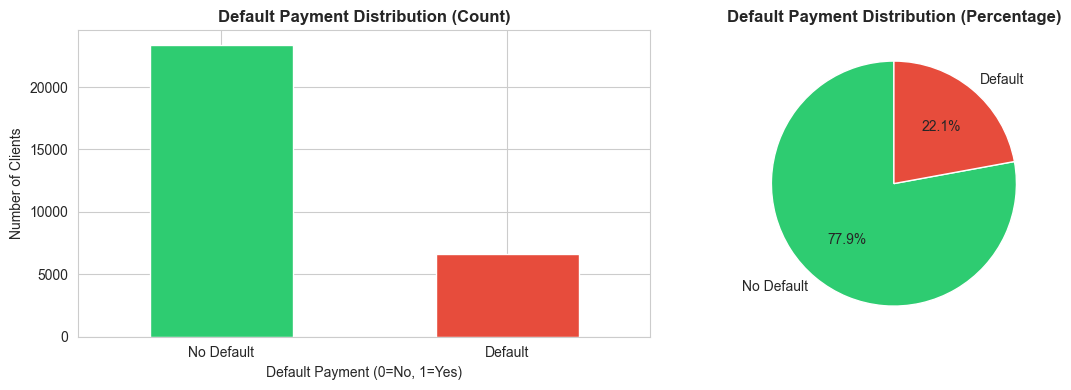


⚠️ Note: Dataset has class imbalance - significantly more non-defaulters than defaulters


In [7]:
# Analyze target default variable distribution
target_counts = df['default payment next month'].value_counts()
target_pct = df['default payment next month'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print(f"No Default (0): {target_counts[0]} clients ({target_pct[0]:.2f}%)")
print(f"Default (1): {target_counts[1]} clients ({target_pct[1]:.2f}%)")
print(f"\nClass Imbalance Ratio: 1:{target_counts[0]/target_counts[1]:.2f}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Default Payment Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Default Payment (0=No, 1=Yes)')
axes[0].set_ylabel('Number of Clients')
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(target_counts, labels=['No Default', 'Default'], autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Default Payment Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n⚠️ Note: Dataset has class imbalance - significantly more non-defaulters than defaulters")

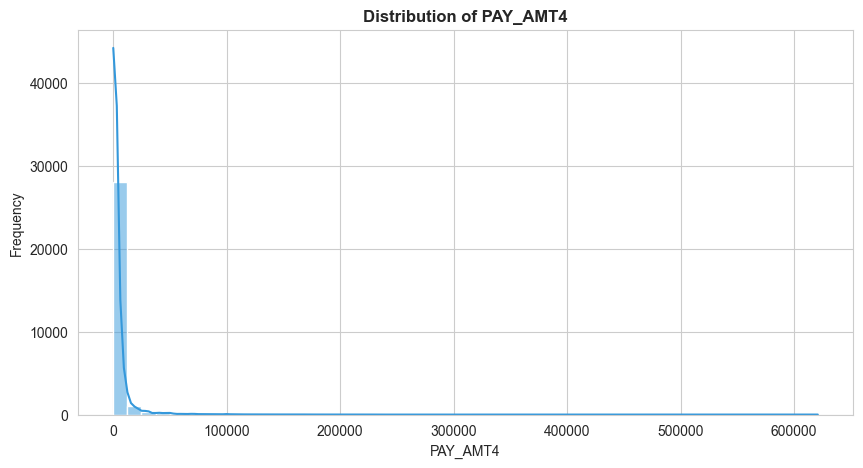

PAY_AMT4 - Zero Values: 6408 (21.36%)
count     23592.000000
mean       6136.923788
std       17437.005758
min           1.000000
10%         499.000000
25%        1000.000000
50%        2200.000000
75%        5000.000000
90%       10545.400000
95%       20017.350000
99%       78807.950000
max      621000.000000
Name: PAY_AMT4, dtype: float64


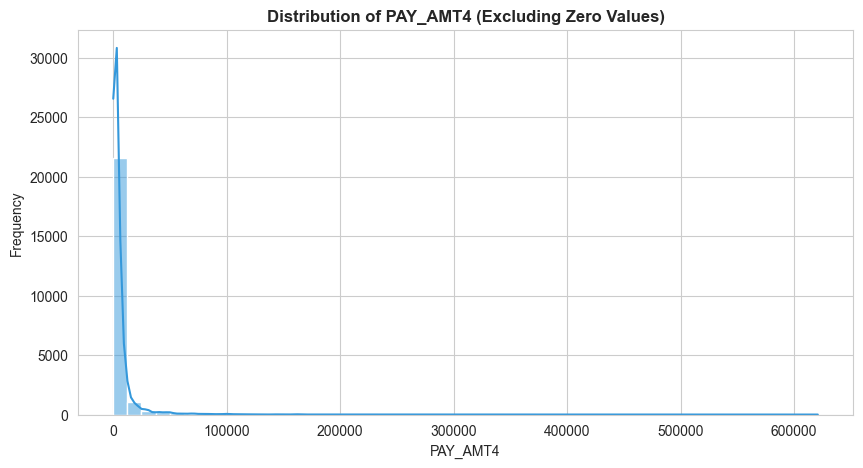

PAY_AMT4 - Outliers (Above 99th Percentile): 300 (1.00%)
count    23292.000000
mean      4605.747939
std       7405.420985
min          1.000000
10%        491.000000
25%       1000.000000
50%       2127.500000
75%       5000.000000
90%      10000.000000
95%      16613.350000
99%      43033.030000
max      67052.000000
Name: PAY_AMT4, dtype: float64


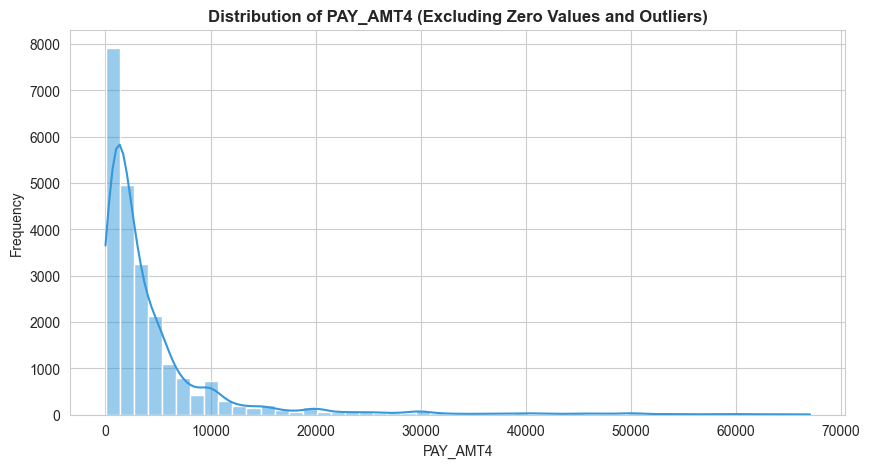

In [8]:
# Analyze second target variable distribution (PAY_AMT4) as continuos variable
plt.figure(figsize=(10, 5))
sns.histplot(df['PAY_AMT4'], bins=50, kde=True, color='#3498db')
plt.title('Distribution of PAY_AMT4', fontsize=12, fontweight='bold')
plt.xlabel('PAY_AMT4')
plt.ylabel('Frequency')
plt.show()

# Additional analysis of PAY_AMT4 distribution excluding zero
print(f"PAY_AMT4 - Zero Values: {(df['PAY_AMT4'] == 0).sum()} ({(df['PAY_AMT4'] == 0).mean() * 100:.2f}%)")
print(df[df['PAY_AMT4'] > 0]['PAY_AMT4'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
plt.figure(figsize=(10, 5))
sns.histplot(df[df['PAY_AMT4'] > 0]['PAY_AMT4'], bins=50, kde=True, color='#3498db')
plt.title('Distribution of PAY_AMT4 (Excluding Zero Values)', fontsize=12, fontweight='bold')
plt.xlabel('PAY_AMT4')
plt.ylabel('Frequency')
plt.show()

# Additional analysis of PAY_AMT4 distribution excluding zero and outliers
print(f"PAY_AMT4 - Outliers (Above 99th Percentile): {(df['PAY_AMT4'] > df['PAY_AMT4'].quantile(0.99)).sum()} ({(df['PAY_AMT4'] > df['PAY_AMT4'].quantile(0.99)).mean() * 100:.2f}%)")
pay_amt4_no_outliers = df[(df['PAY_AMT4'] > 0) & (df['PAY_AMT4'] < df['PAY_AMT4'].quantile(0.99))]['PAY_AMT4']
print(pay_amt4_no_outliers.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
plt.figure(figsize=(10, 5))
sns.histplot(df[(df['PAY_AMT4'] > 0) & (df['PAY_AMT4'] < df['PAY_AMT4'].quantile(0.99))]['PAY_AMT4'], bins=50, kde=True, color='#3498db')
plt.title('Distribution of PAY_AMT4 (Excluding Zero Values and Outliers)', fontsize=12, fontweight='bold')
plt.xlabel('PAY_AMT4')
plt.ylabel('Frequency')
plt.show()


Correlation Analysis: PAY_AMT4 vs Default Payment Next Month


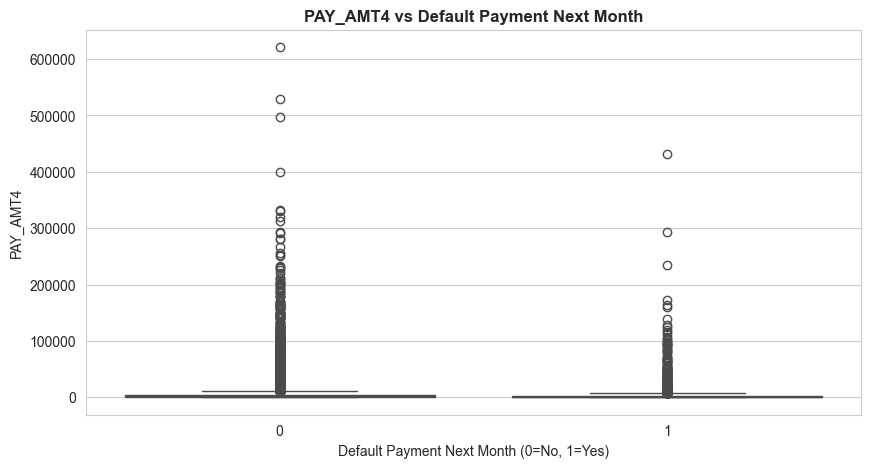

In [9]:
# Correlation analysis between PAY_AMT4 and default payment next month
print("\nCorrelation Analysis: PAY_AMT4 vs Default Payment Next Month")
plt.figure(figsize=(10, 5))
sns.boxplot(x='default payment next month', y='PAY_AMT4', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('PAY_AMT4 vs Default Payment Next Month', fontsize=12, fontweight='bold')
plt.xlabel('Default Payment Next Month (0=No, 1=Yes)') 
plt.ylabel('PAY_AMT4')
plt.show()

### Resumen de Insights - Distribución de Variables Objetivo

#### 1. Variable Objetivo Principal: Default Payment Next Month

##### Distribución General
- **No Default (0)**: 23,364 clientes (77.88%)
- **Default (1)**: 6,636 clientes (22.12%)
- **Ratio de Desbalance**: 1:3.52 (por cada cliente que incumple, hay 3.52 que no incumplen)

##### Insights Clave
- El dataset presenta un **desbalance de clase significativo** con una mayoría clara de no morosos
- Los clientes morosos representan aproximadamente 1 de cada 5 clientes
- Esta proporción es típica en datos de riesgo crediticio pero requiere técnicas especiales de modelado
- Es indispensable usar validación estratificada, ponderación de clases o técnicas de remuestreo (SMOTE) para mitigar el desbalance

---

#### 2. Variable Secundaria: PAY_AMT4 (Monto de Pago - Junio 2005)

##### Distribución General
- **Ceros en los datos**: 6,408 registros (21.36%)
- **Valores positivos**: Altamente sesgados a la derecha
- **Rango**: Desde NT $0 hasta valores muy elevados
- Distribución aparentemente exponencial

##### Patrones Observados
- **Alta concentración en cero**: Muchos clientes no realizaron pagos en junio
- **Distribución muy asimétrica**: La mayoría de pagos son bajos, con pocos pagos muy grandes
- 75% de los clientes cuentan con pagos menores de 5000 NT
- **Outliers significativos**: Existen clientes con pagos extremadamente altos con una diferencia máxima de 542,193 NT.

##### Recomendaciones
- Tratar los ceros por separado como variable indicadora de no-pago
- Aplicar transformación logarítmica (log1p) para normalizar la distribución
- Considerar crear variables binarias: "pagó" vs "no pagó"
- Excluir outliers extremos en análisis univariados pero retenerlos en modelos

---

#### 3. Relación entre Variables Objetivo y Comportamiento de Pago

##### Insights Principales
- **Pagos atrasados**: El estado de retraso en pagos (PAY_0, PAY_2, etc.) es el predictor más fuerte del default
- **Correlación con default**: 0.3248 para PAY_0 (estado más reciente), disminuyendo para meses anteriores
- **Patrón temporal**: Los retrasos recientes tienen más impacto que los históricos

##### Conclusiones
- La **conducta de pago reciente** es crítica para predecir default
- Los clientes sin historial de retrasos tienen tasas de default mucho menores
- El comportamiento de pago es más predictivo que características demográficas

---

#### Recomendaciones para Modelado
1. Manejar el desbalance de clase (22% positivo) antes de entrenar modelos
2. Priorizar features de comportamiento de pago sobre características demográficas
3. Transformar variables de pago altamente sesgadas
4. Usar métricas apropiadas: AUC-ROC, Precision-Recall, F1 en lugar de solo accuracy
5. Validar con cross-validation estratificada

## 4. Demographic Analysis

In [10]:
# Create mapping dictionaries for better interpretation
sex_map = {1: 'Male', 2: 'Female'}
education_map = {0: 'No education', 1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others', 5: 'Unknown_5', 6: 'Unknown_6'}
marriage_map = {0: 'Unknown_0', 1: 'Married', 2: 'Single', 3: 'Others'}

remap_df = df.copy()
remap_df['SEX'] = remap_df['SEX'].map(sex_map)
remap_df['EDUCATION'] = remap_df['EDUCATION'].map(education_map)
remap_df['MARRIAGE'] = remap_df['MARRIAGE'].map(marriage_map)

# Analyze Age distribution
print("AGE DISTRIBUTION:")
print(remap_df['AGE'].describe())
print(f"\nAge Range: {remap_df['AGE'].min()} to {remap_df['AGE'].max()} years")

# Analyze Sex distribution
print("\nSEX DISTRIBUTION:")
print(f"Gender Ratio (M:F): {remap_df[remap_df['SEX']=="Male"].shape[0]}:{remap_df[remap_df['SEX']=="Female"].shape[0]}")
print(remap_df.stb.freq(['SEX']))

# Analyze Education distribution
print("\nEDUCATION DISTRIBUTION:")
print(remap_df.stb.freq(['EDUCATION']))

# Analyze Marital Status distribution
print("\nMARITAL STATUS DISTRIBUTION:")
print(remap_df.stb.freq(['MARRIAGE']))

AGE DISTRIBUTION:
count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

Age Range: 21 to 79 years

SEX DISTRIBUTION:
Gender Ratio (M:F): 11888:18112
      SEX  count    percent  cumulative_count  cumulative_percent
0  Female  18112  60.373333             18112           60.373333
1    Male  11888  39.626667             30000          100.000000

EDUCATION DISTRIBUTION:
      EDUCATION  count    percent  cumulative_count  cumulative_percent
0    University  14030  46.766667             14030           46.766667
1      Graduate  10585  35.283333             24615           82.050000
2   High School   4917  16.390000             29532           98.440000
3     Unknown_5    280   0.933333             29812           99.373333
4        Others    123   0.410000             29935           99.783333
5     Unknown_6     51   0.170000             2

#### Educación
**Nota:** en la documentación del dataset proporcionada en el ejercicio los valores de EDUCATION deberían ser: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown). Por otro lado, en la documentación de metadata del dataset se informa: (1 = graduate school; 2 = university; 3 = high school; 4 = others). No obstante, observamos valores entre 0 y 6. 

- Asumimos que la lógica de la información correspondería 0 = "Sin educación" o bien puede considerarse un valor inputado para un dato faltante.
- Nótese que entre las cuatro categorías (0, 4, 5 y 6) se alcanza 1.5% de los datos. Por lo que consideramos posible englobarlas dentro de 'Others' a excepción del valor 0, debido al supuesto anterior.

#### Estado civil
**Nota:** en la documentación del dataset proporcionada en el ejercicio los valores de MARRIAGE deberían ser: (1=married, 2=single, 3=others). No obstante, observamos valores entre 0 y 3. 

- Asumimos que esto puede considerar un valor inputado para un dato faltante.
- Nótese que el valor 0 almacena 0.18% de los datos.

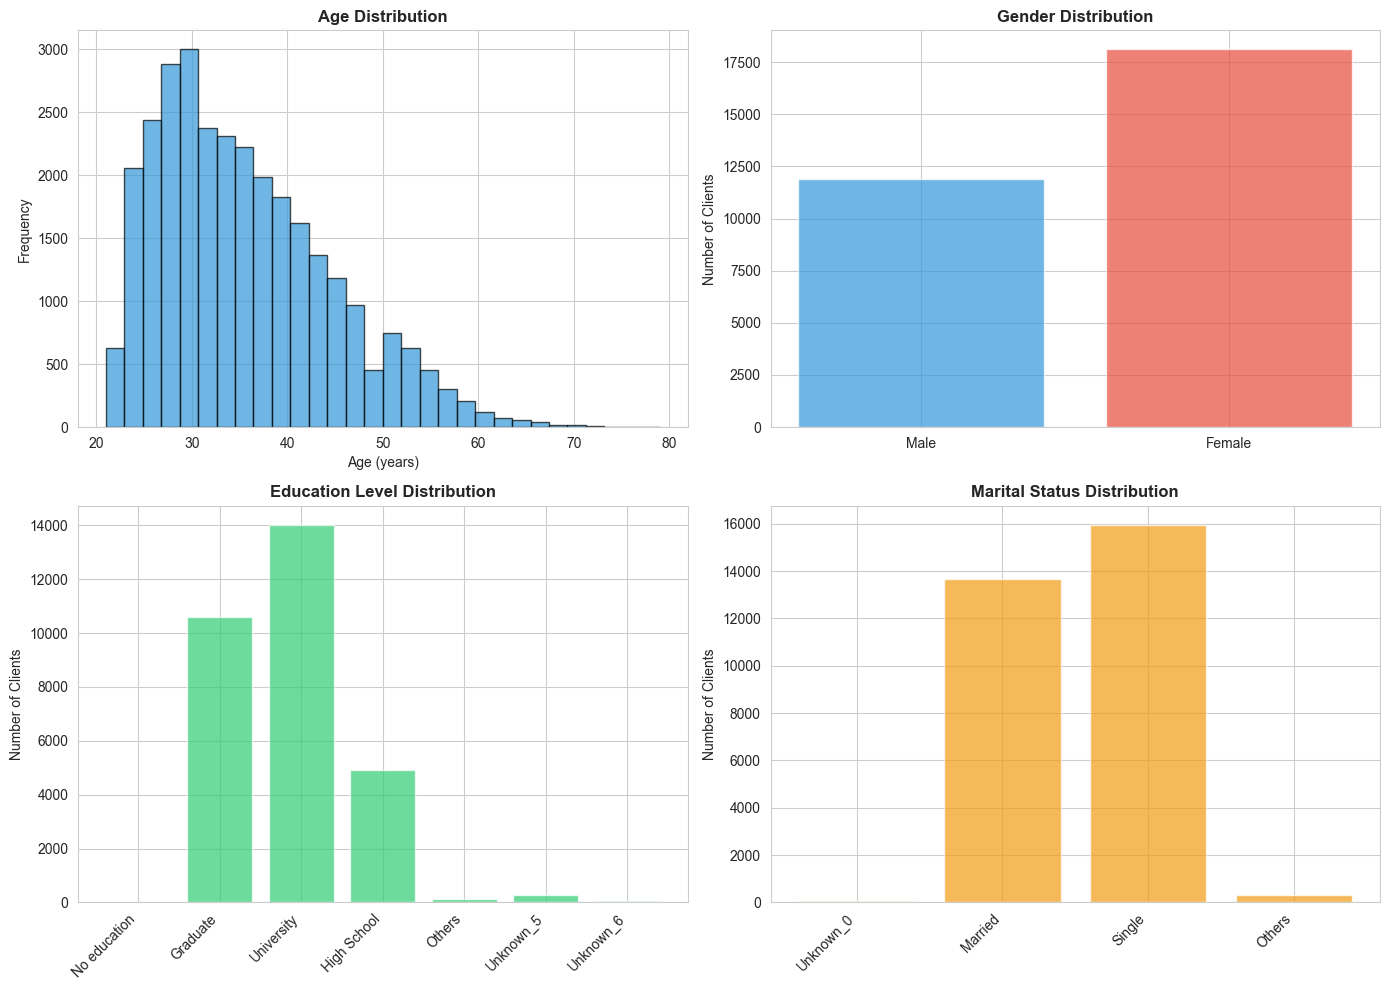

In [11]:
# Visualize demographics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
axes[0, 0].hist(df['AGE'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Frequency')

# Sex distribution
sex_counts = df['SEX'].value_counts().sort_index()
axes[0, 1].bar(['Male', 'Female'], sex_counts.values, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0, 1].set_title('Gender Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Number of Clients')

# Education distribution
edu_counts = df['EDUCATION'].value_counts().sort_index()
education_labels = [education_map.get(i, f'Unknown ({i})') for i in edu_counts.index]
axes[1, 0].bar(range(len(edu_counts)), edu_counts.values, color='#2ecc71', alpha=0.7)
axes[1, 0].set_xticks(range(len(edu_counts)))
axes[1, 0].set_xticklabels(education_labels, rotation=45, ha='right')
axes[1, 0].set_title('Education Level Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Clients')

# Marital Status distribution
mar_counts = df['MARRIAGE'].value_counts().sort_index()
marital_labels = [marriage_map.get(i, f'Unknown ({i})') for i in mar_counts.index]
axes[1, 1].bar(range(len(mar_counts)), mar_counts.values, color='#f39c12', alpha=0.7)
axes[1, 1].set_xticks(range(len(mar_counts)))
axes[1, 1].set_xticklabels(marital_labels, rotation=45, ha='right')
axes[1, 1].set_title('Marital Status Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Clients')

plt.tight_layout()
plt.show()


ANALYSIS OF UNKNOWN CATEGORIES AGAINST DEFAULT TARGET VARIABLE:
---------------------------------------------------------------------------
EDUCATION
       EDUCATION  default payment next month  count    percent  \
0     University                           0  10700  35.666667   
1       Graduate                           0   8549  28.496667   
2    High School                           0   3680  12.266667   
3     University                           1   3330  11.100000   
4       Graduate                           1   2036   6.786667   
5    High School                           1   1237   4.123333   
6      Unknown_5                           0    262   0.873333   
7         Others                           0    116   0.386667   
8      Unknown_6                           0     43   0.143333   
9      Unknown_5                           1     18   0.060000   
10  No education                           0     14   0.046667   
11     Unknown_6                           1      8   0.0

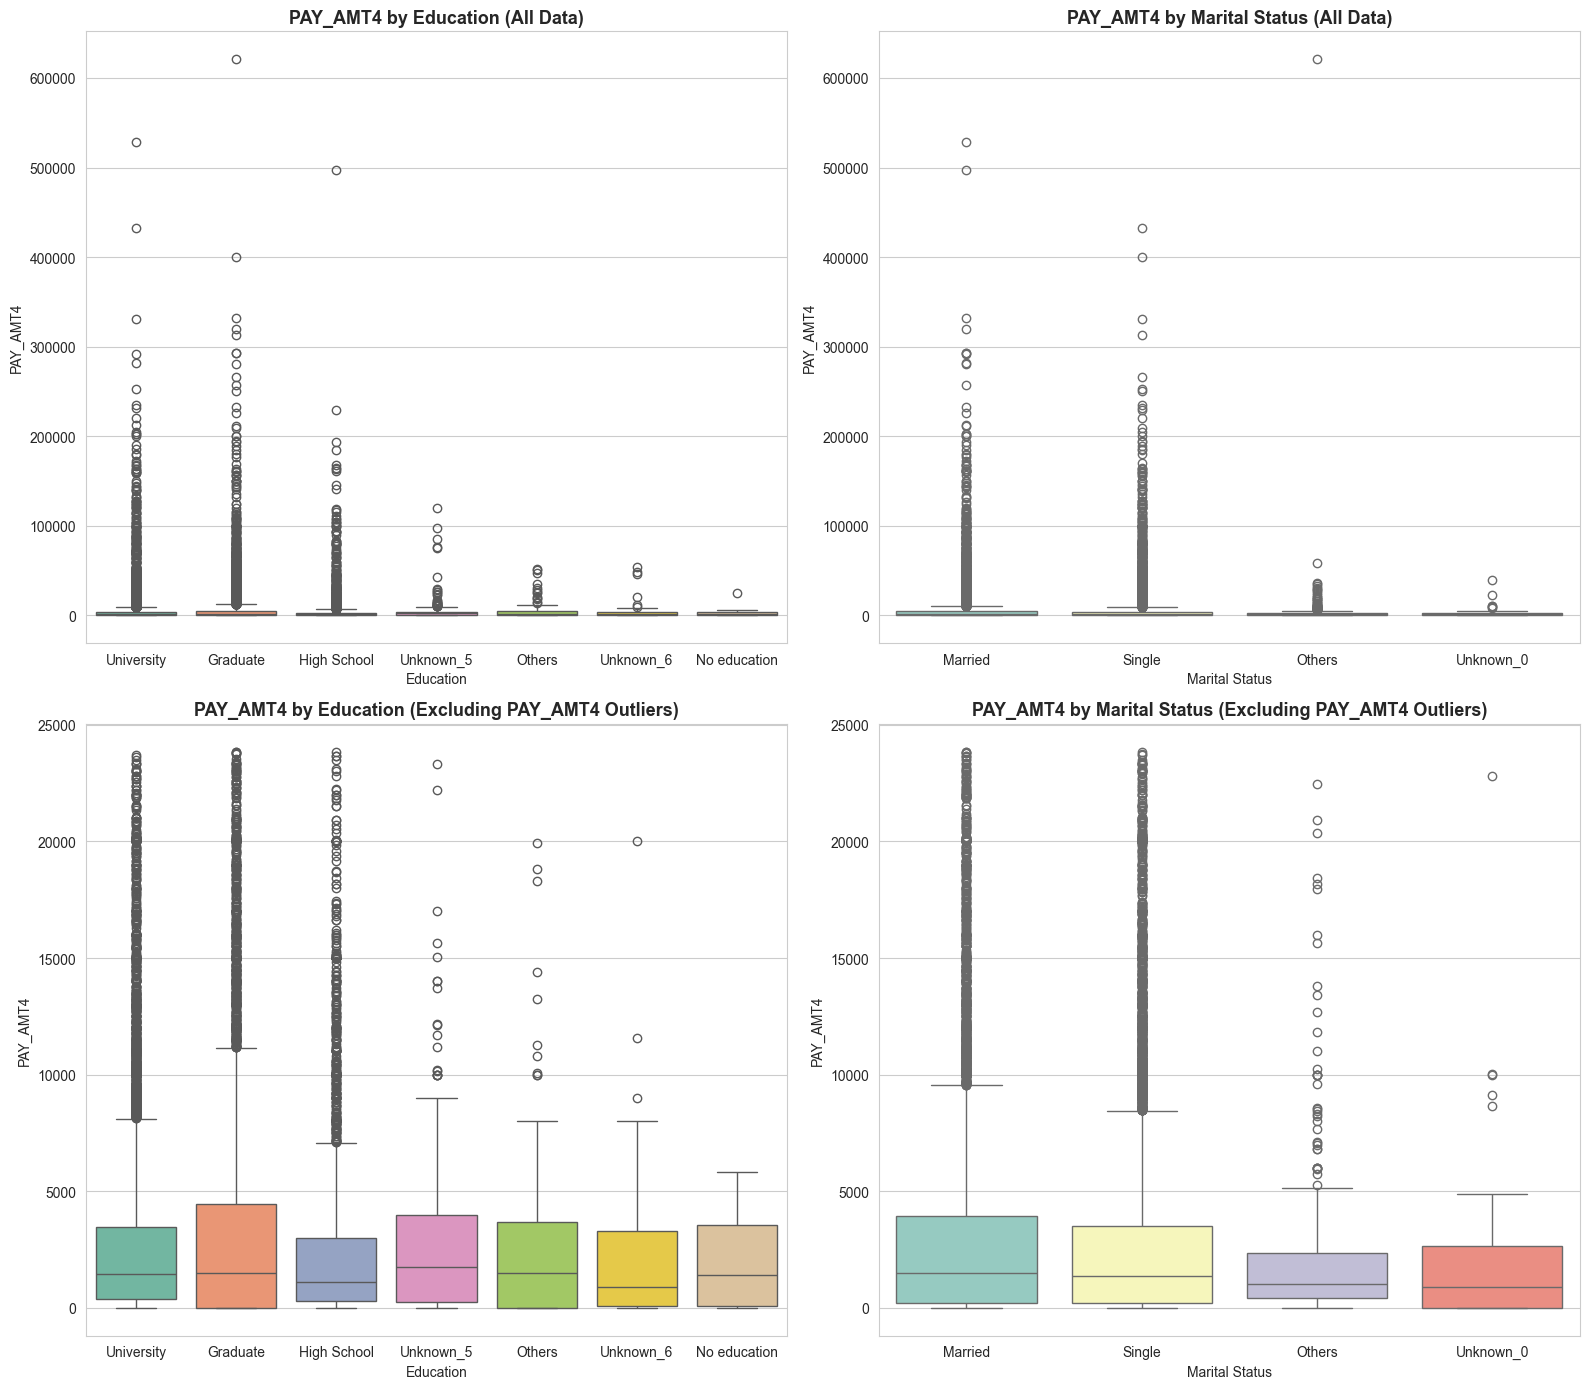

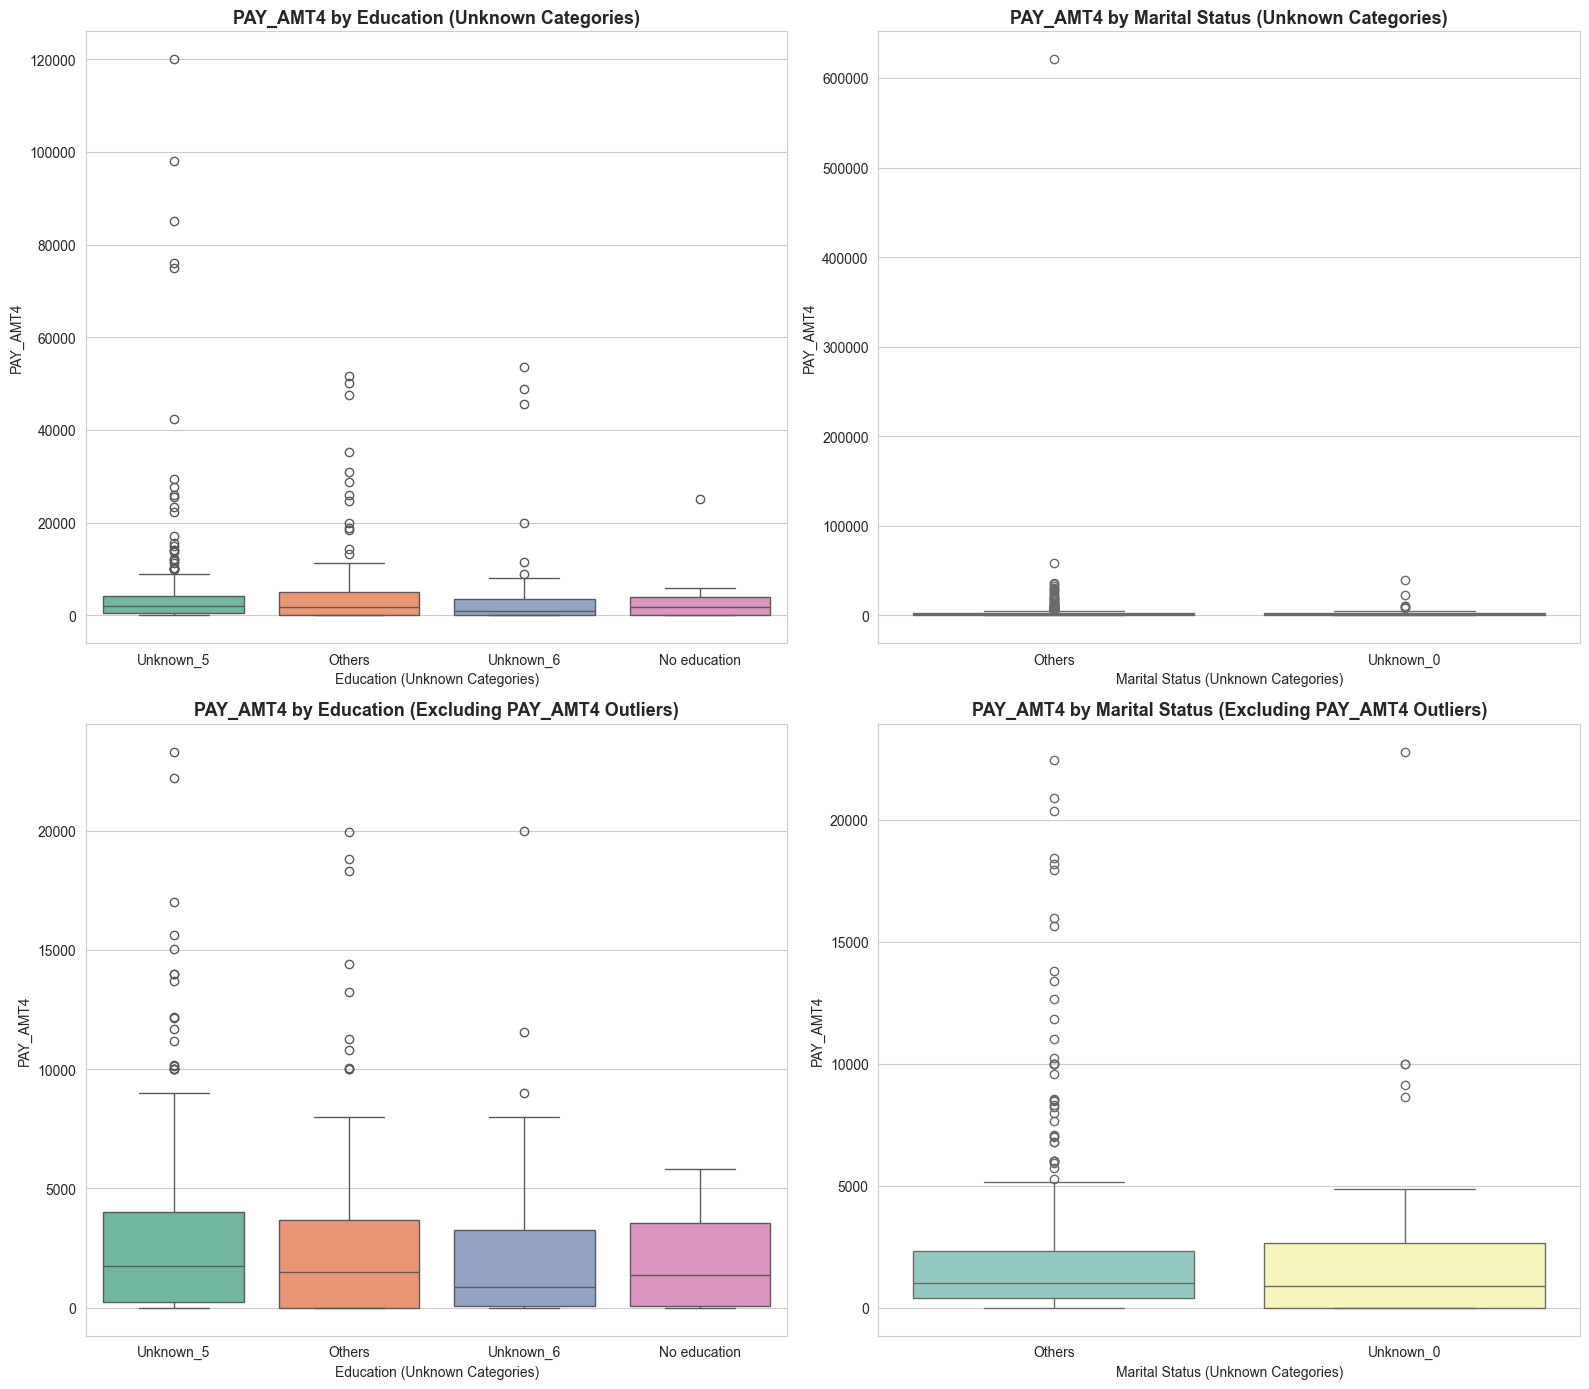

In [12]:
# ------------------- Analysis of Unknown categories against target variable
print("\nANALYSIS OF UNKNOWN CATEGORIES AGAINST DEFAULT TARGET VARIABLE:")
print('-'*75)
print("EDUCATION")
print(remap_df.stb.freq(['EDUCATION', 'default payment next month']))
print('-'*75)
print("MARRIAGE")
print(remap_df.stb.freq(['MARRIAGE', 'default payment next month']))
print("="*75)
print("\nANALYSIS OF UNKNOWN CATEGORIES AGAINST PAYMENT TARGET VARIABLE:")
print('-'*75)


# Boxplots of PAY_AMT4 vs EDUCATION and MARRIAGE with and without outliers
pay_amt4_p1 = remap_df['PAY_AMT4'].quantile(0.1)
pay_amt4_p9 = remap_df['PAY_AMT4'].quantile(0.9)
pay_amt4_iqr = pay_amt4_p9 - pay_amt4_p1
lower_bound = pay_amt4_p1 - 1.5 * pay_amt4_iqr
upper_bound = pay_amt4_p9 + 1.5 * pay_amt4_iqr

remap_no_outliers = remap_df[
    (remap_df['PAY_AMT4'] >= lower_bound) &
    (remap_df['PAY_AMT4'] <= upper_bound)
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

sns.boxplot(
    x='EDUCATION', y='PAY_AMT4', data=remap_df,
    ax=axes[0, 0], palette='Set2'
)
axes[0, 0].set_title('PAY_AMT4 by Education (All Data)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Education')
axes[0, 0].set_ylabel('PAY_AMT4')

sns.boxplot(
    x='MARRIAGE', y='PAY_AMT4', data=remap_df,
    ax=axes[0, 1], palette='Set3'
)
axes[0, 1].set_title('PAY_AMT4 by Marital Status (All Data)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Marital Status')
axes[0, 1].set_ylabel('PAY_AMT4')

sns.boxplot(
    x='EDUCATION', y='PAY_AMT4', data=remap_no_outliers,
    ax=axes[1, 0], palette='Set2'
)
axes[1, 0].set_title('PAY_AMT4 by Education (Excluding PAY_AMT4 Outliers)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Education')
axes[1, 0].set_ylabel('PAY_AMT4')

sns.boxplot(
    x='MARRIAGE', y='PAY_AMT4', data=remap_no_outliers,
    ax=axes[1, 1], palette='Set3'
)
axes[1, 1].set_title('PAY_AMT4 by Marital Status (Excluding PAY_AMT4 Outliers)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Marital Status')
axes[1, 1].set_ylabel('PAY_AMT4')

plt.tight_layout()
plt.show()

print("="*80)
print("="*80)

# Boxplots only for unknown categories
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
remap_unknown_edu = remap_df[remap_df['EDUCATION'].isin(['No education', 'Others', 'Unknown_5', 'Unknown_6'])]
remap_unknown_marriage = remap_df[remap_df['MARRIAGE'].isin(['Unknown_0', 'Others'])]

remap_unknown_edu_no_outliers = remap_no_outliers[remap_no_outliers['EDUCATION'].isin(['No education', 'Others', 'Unknown_5', 'Unknown_6'])]
remap_unknown_marriage_no_outliers = remap_no_outliers[remap_no_outliers['MARRIAGE'].isin(['Unknown_0', 'Others'])]

sns.boxplot(
    x='EDUCATION', y='PAY_AMT4', data=remap_unknown_edu,
    ax=axes[0, 0], palette='Set2'
)
axes[0, 0].set_title('PAY_AMT4 by Education (Unknown Categories)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Education (Unknown Categories)')
axes[0, 0].set_ylabel('PAY_AMT4')

sns.boxplot(
    x='MARRIAGE', y='PAY_AMT4', data=remap_unknown_marriage,
    ax=axes[0, 1], palette='Set3'
)
axes[0, 1].set_title('PAY_AMT4 by Marital Status (Unknown Categories)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Marital Status (Unknown Categories)')
axes[0, 1].set_ylabel('PAY_AMT4')

sns.boxplot(
    x='EDUCATION', y='PAY_AMT4', data=remap_unknown_edu_no_outliers,
    ax=axes[1, 0], palette='Set2'
)
axes[1, 0].set_title('PAY_AMT4 by Education (Excluding PAY_AMT4 Outliers)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Education (Unknown Categories)')
axes[1, 0].set_ylabel('PAY_AMT4')

sns.boxplot(
    x='MARRIAGE', y='PAY_AMT4', data=remap_unknown_marriage_no_outliers,
    ax=axes[1, 1], palette='Set3'
)
axes[1, 1].set_title('PAY_AMT4 by Marital Status (Excluding PAY_AMT4 Outliers)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Marital Status (Unknown Categories)')
axes[1, 1].set_ylabel('PAY_AMT4')

plt.tight_layout()
plt.show()

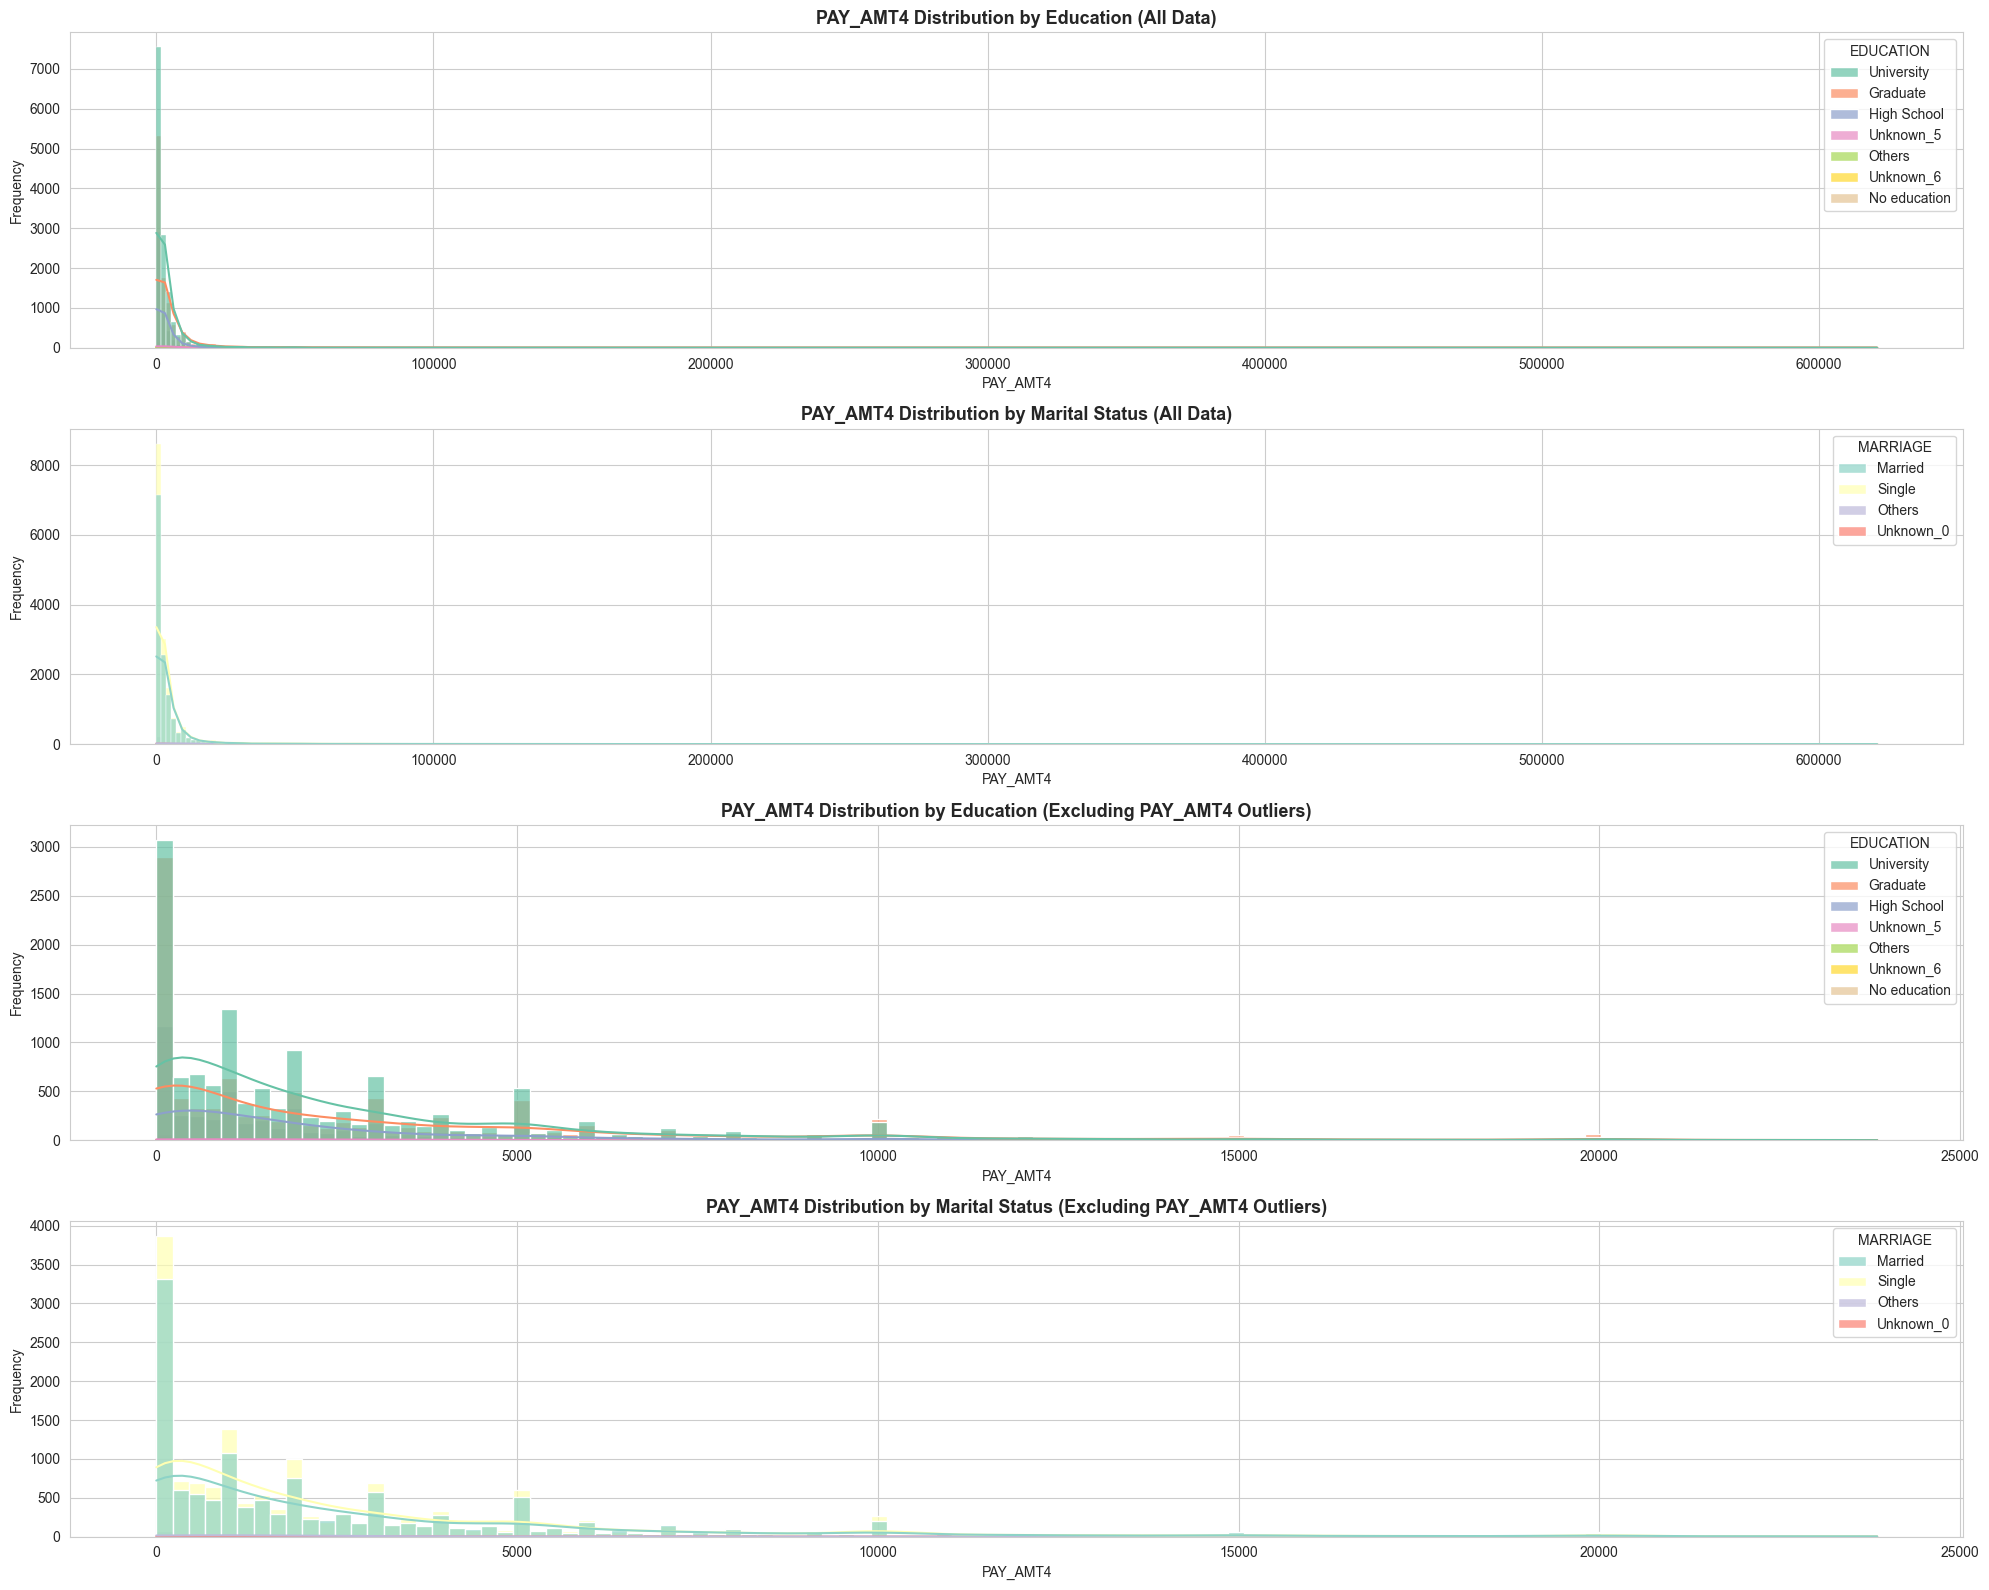

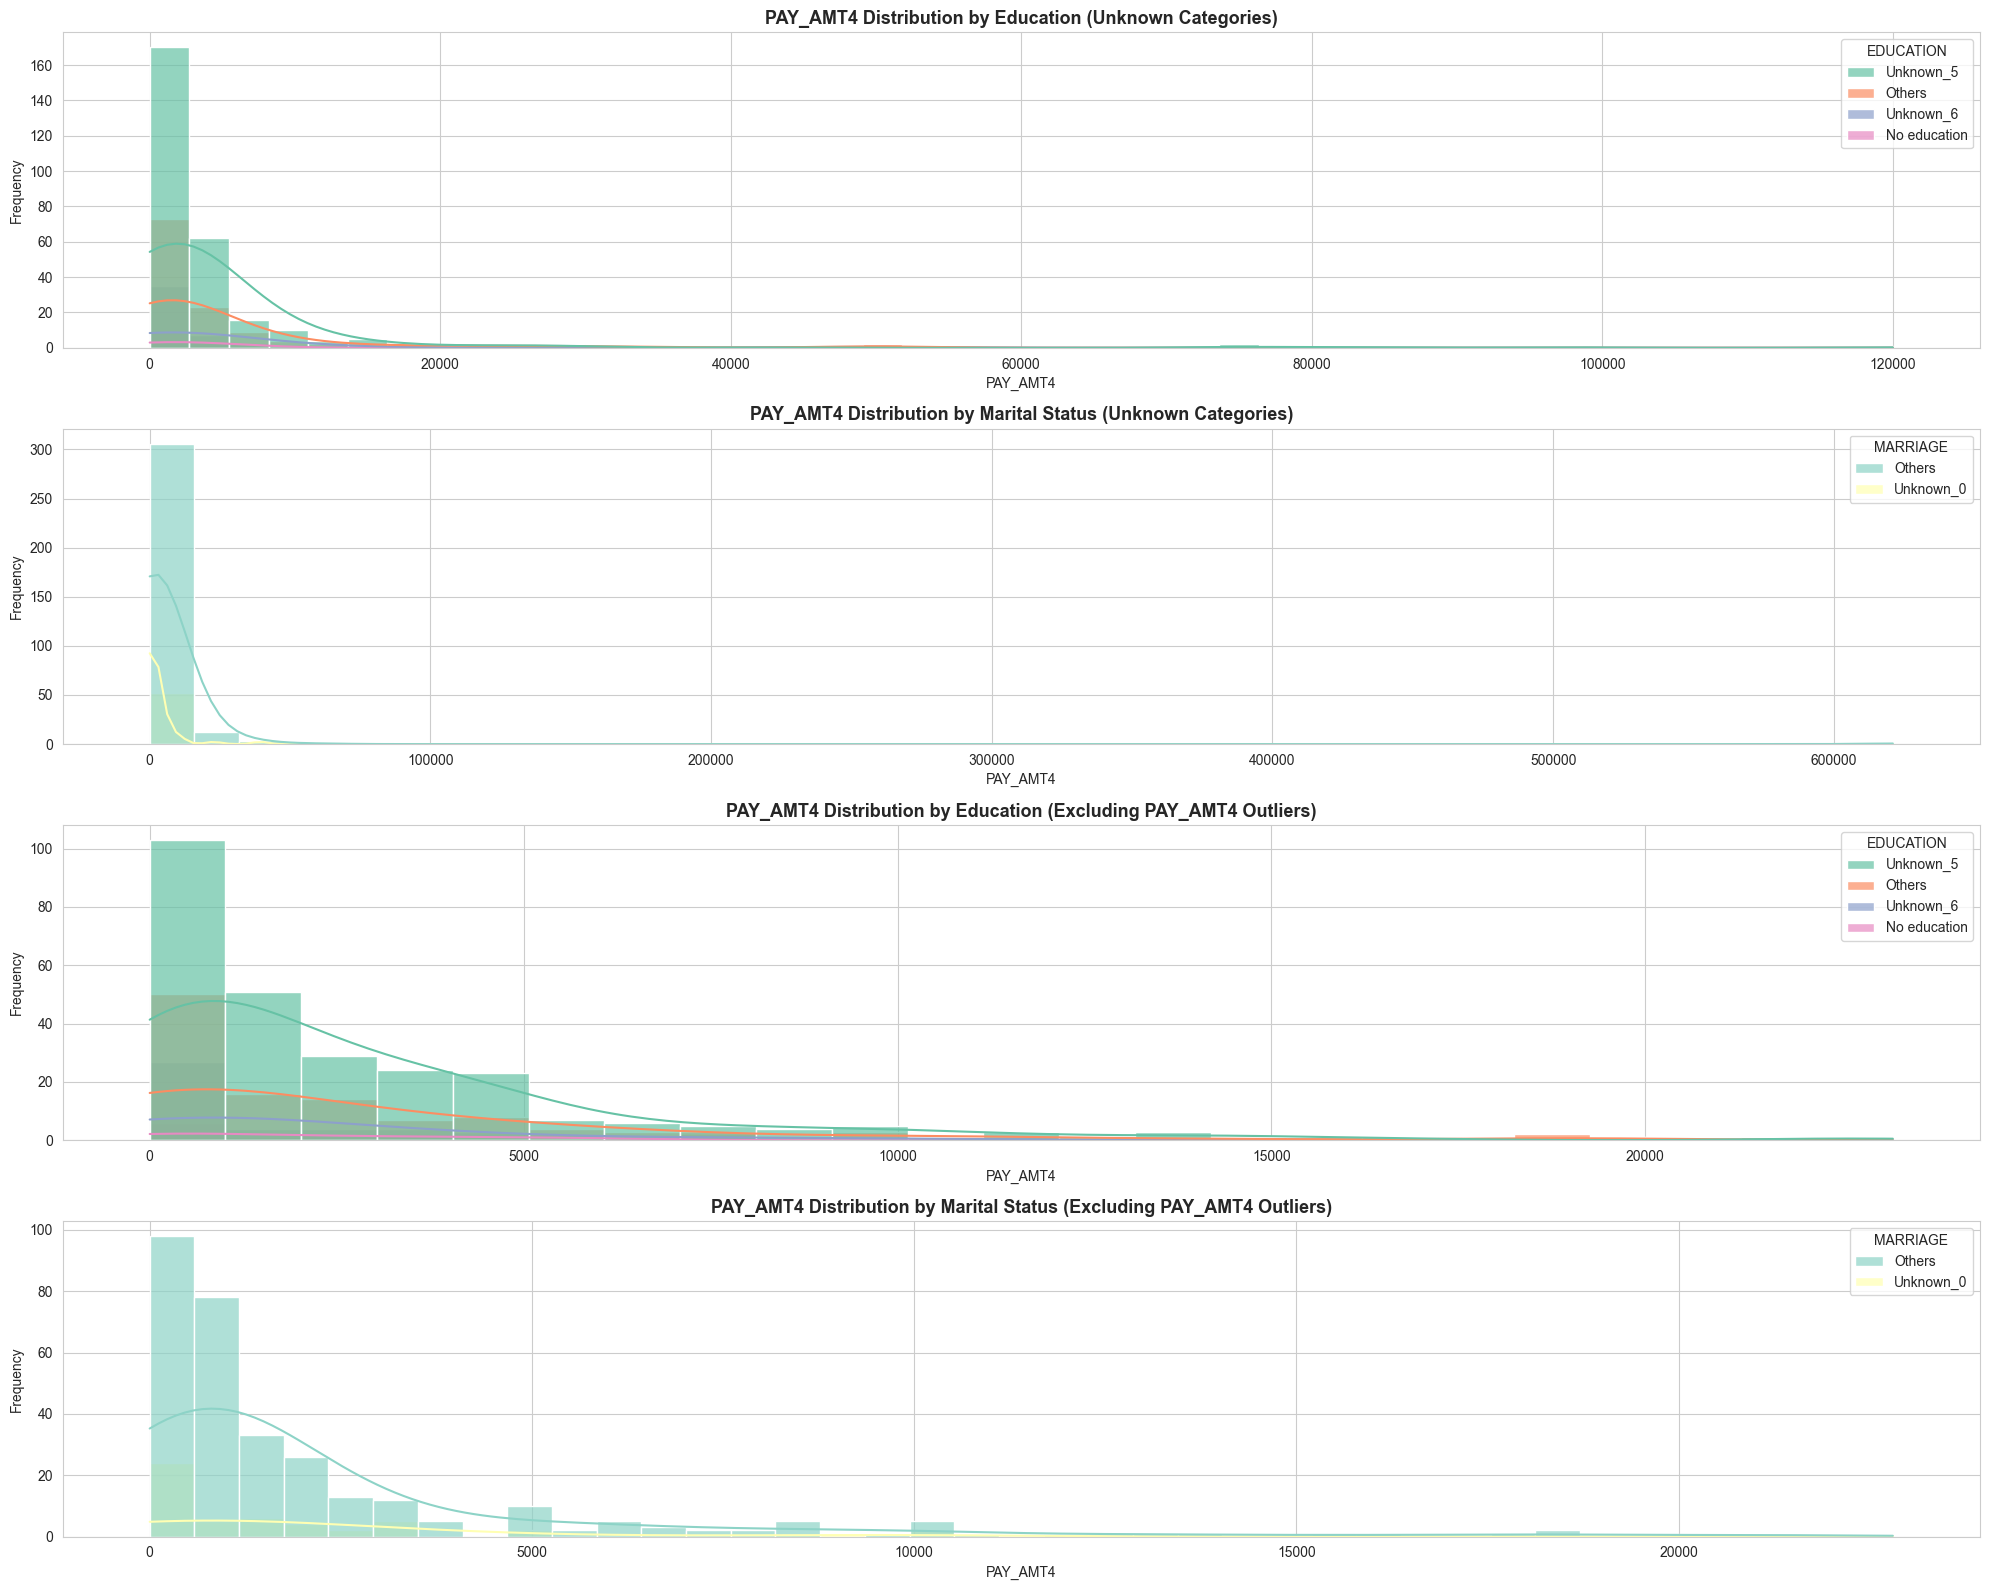

In [13]:
# Same code but with histograms

fig, axes = plt.subplots(4, 1, figsize=(20, 16))

sns.histplot(
    data=remap_df, x='PAY_AMT4', hue='EDUCATION', ax=axes[0], 
    palette='Set2', multiple='layer', alpha=0.7, kde=True
)
axes[0].set_title('PAY_AMT4 Distribution by Education (All Data)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PAY_AMT4')
axes[0].set_ylabel('Frequency')

sns.histplot(
    data=remap_df, x='PAY_AMT4', hue='MARRIAGE', ax=axes[1], 
    palette='Set3', multiple='layer', alpha=0.7, kde=True
)
axes[1].set_title('PAY_AMT4 Distribution by Marital Status (All Data)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PAY_AMT4')
axes[1].set_ylabel('Frequency')

sns.histplot(
    data=remap_no_outliers, x='PAY_AMT4', hue='EDUCATION', ax=axes[2], 
    palette='Set2', multiple='layer', alpha=0.7, kde=True
)
axes[2].set_title('PAY_AMT4 Distribution by Education (Excluding PAY_AMT4 Outliers)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('PAY_AMT4')
axes[2].set_ylabel('Frequency')

sns.histplot(
    data=remap_no_outliers, x='PAY_AMT4', hue='MARRIAGE', ax=axes[3], 
    palette='Set3', multiple='layer', alpha=0.7, kde=True
)
axes[3].set_title('PAY_AMT4 Distribution by Marital Status (Excluding PAY_AMT4 Outliers)', fontsize=13, fontweight='bold')
axes[3].set_xlabel('PAY_AMT4')
axes[3].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("="*80)
print("="*80)

# With unknown categories only
fig, axes = plt.subplots(4, 1, figsize=(20, 16))

sns.histplot(
    data=remap_unknown_edu, x='PAY_AMT4', hue='EDUCATION', ax=axes[0], 
    palette='Set2', multiple='layer', alpha=0.7, kde=True
)
axes[0].set_title('PAY_AMT4 Distribution by Education (Unknown Categories)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PAY_AMT4')
axes[0].set_ylabel('Frequency')

sns.histplot(
    data=remap_unknown_marriage, x='PAY_AMT4', hue='MARRIAGE', ax=axes[1], 
    palette='Set3', multiple='layer', alpha=0.7, kde=True
)
axes[1].set_title('PAY_AMT4 Distribution by Marital Status (Unknown Categories)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PAY_AMT4')
axes[1].set_ylabel('Frequency')

sns.histplot(
    data=remap_unknown_edu_no_outliers, x='PAY_AMT4', hue='EDUCATION', ax=axes[2], 
    palette='Set2', multiple='layer', alpha=0.7, kde=True
)
axes[2].set_title('PAY_AMT4 Distribution by Education (Excluding PAY_AMT4 Outliers)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('PAY_AMT4')
axes[2].set_ylabel('Frequency')

sns.histplot(
    data=remap_unknown_marriage_no_outliers, x='PAY_AMT4', hue='MARRIAGE', ax=axes[3], 
    palette='Set3', multiple='layer', alpha=0.7, kde=True
)
axes[3].set_title('PAY_AMT4 Distribution by Marital Status (Excluding PAY_AMT4 Outliers)', fontsize=13, fontweight='bold')
axes[3].set_xlabel('PAY_AMT4')
axes[3].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Conclusiones generales - Análisis Demográfico

- La muestra presenta una mayoría de mujeres: 18,112 vs 11,888 hombres.
- La variable de educación contiene valores atípicos respecto a la documentación original, por lo que se reaplicó un mapeo más interpretativo:
    - 1 = Graduate
    - 2 = University
    - 3 = High School
    - 4, 5, 6 y 0 se consideran categorías de “Others” / desconocido.
- El estado civil también muestra valores fuera del rango esperado, con `0` indicando una categoría desconocida o imputada.
- Respecto a la relación con la variable objetivo:
    - la proporción de sexos y las categorías demográficas ofrecen contexto, pero no reemplazan la información de los estados de pago.
- Recomendación:
    - tratar `EDUCATION` y `MARRIAGE` con recodificación o agrupación de **categorías raras** (pendiente de verificar pasos a seguir - **tirar/agrupar**)
    - usar demografía como información complementaria

## 5. Credit Limit and Utilization Analysis

CREDIT LIMIT ANALYSIS:
count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

Credit Limit Range: NT$10,000 to NT$1,000,000

Credit Utilization Statistics:
count    30000.000000
mean         0.423771
std          0.411462
min         -0.619892
25%          0.022032
50%          0.313994
75%          0.829843
max          6.455300
Name: credit_utilization, dtype: float64


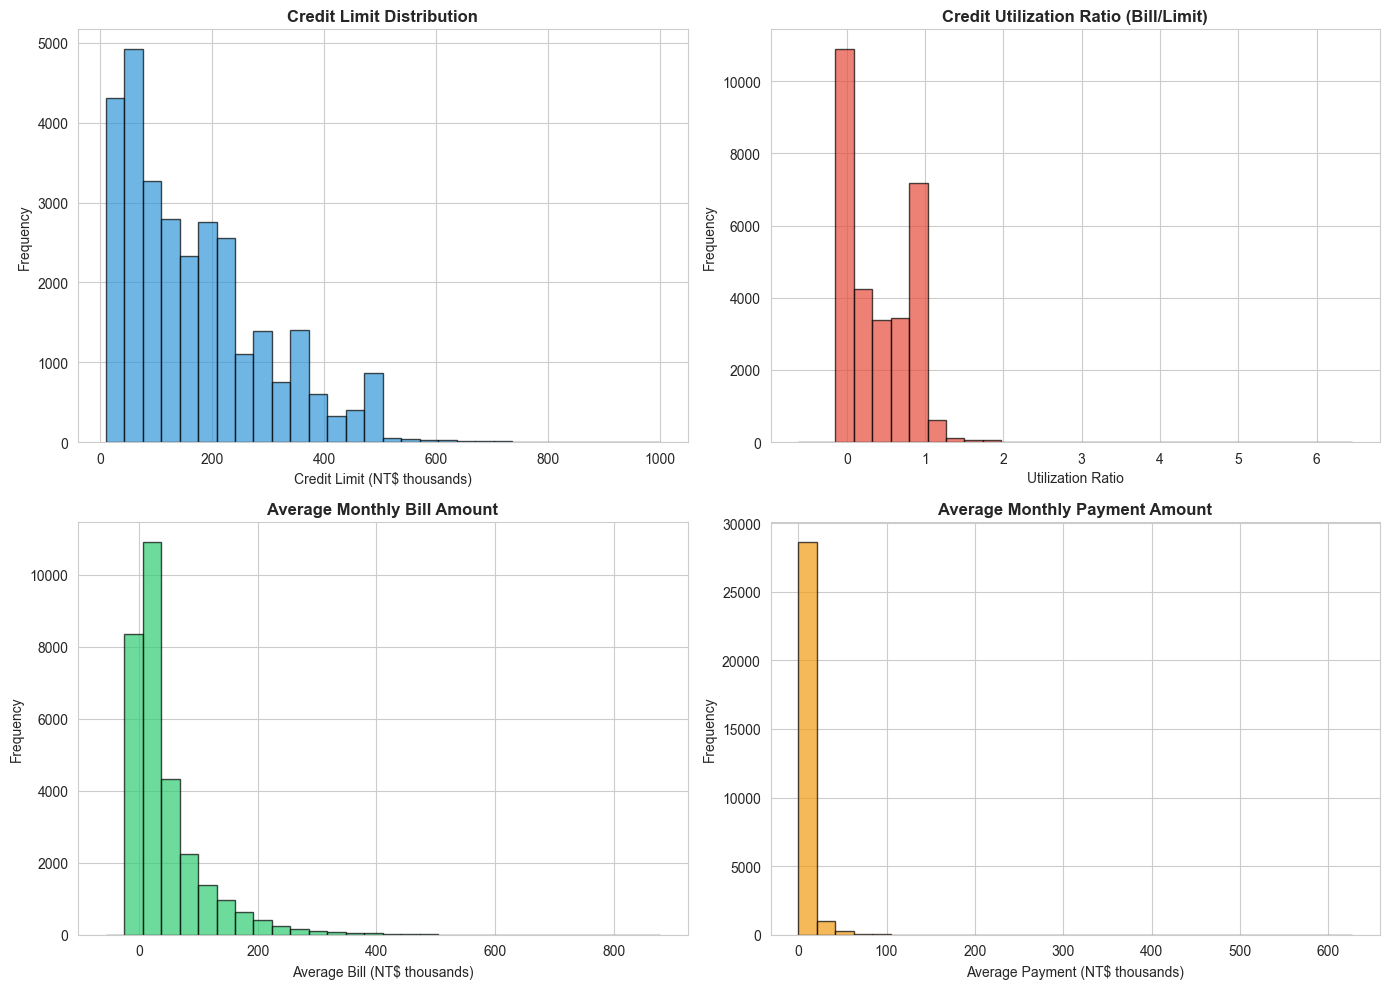


Default Rate by Credit Limit Quartiles:
                 Clients  Defaults  Default Rate
credit_quartile                                 
Q1 (Low)            7676      2440      0.317874
Q2                  7614      1882      0.247176
Q3                  7643      1326      0.173492
Q4 (High)           7067       988      0.139805


In [14]:
# Analyze Credit Limit
print("CREDIT LIMIT ANALYSIS:")
print(df['LIMIT_BAL'].describe())
print(f"\nCredit Limit Range: NT${df['LIMIT_BAL'].min():,.0f} to NT${df['LIMIT_BAL'].max():,.0f}")

# Calculate credit utilization (most recent bill amount / credit limit)
df['credit_utilization'] = df['BILL_AMT1'] / df['LIMIT_BAL']  # BILL_AMT1 is most recent bill amount
print(f"\nCredit Utilization Statistics:")
print(df['credit_utilization'].describe())

# Calculate average monthly bill and payment
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df['avg_monthly_bill'] = df[bill_cols].mean(axis=1)
df['avg_monthly_payment'] = df[pay_amt_cols].mean(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Credit limit distribution
axes[0, 0].hist(df['LIMIT_BAL'] / 1000, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Credit Limit Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Credit Limit (NT$ thousands)')
axes[0, 0].set_ylabel('Frequency')

# Credit utilization distribution
axes[0, 1].hist(df['credit_utilization'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Credit Utilization Ratio (Bill/Limit)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Utilization Ratio')
axes[0, 1].set_ylabel('Frequency')

# Average Monthly Bill
axes[1, 0].hist(df['avg_monthly_bill'] / 1000, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Average Monthly Bill Amount', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Average Bill (NT$ thousands)')
axes[1, 0].set_ylabel('Frequency')

# Average Monthly Payment
axes[1, 1].hist(df['avg_monthly_payment'] / 1000, bins=30, color='#f39c12', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Average Monthly Payment Amount', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Average Payment (NT$ thousands)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Analyze relationship between credit limit and default
print("\nDefault Rate by Credit Limit Quartiles:")
df['credit_quartile'] = pd.qcut(df['LIMIT_BAL'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
print(df.groupby('credit_quartile')['default payment next month'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Clients', 'sum': 'Defaults', 'mean': 'Default Rate'}))

## 6. Payment Status and Behavior Analysis

REPAYMENT STATUS ANALYSIS (Most Recent Month: September 2005)

Value Meanings:
  -1 = Paid in full or within grace period
  0 = Revolving credit / no consumption
  1 = Payment delay for 1 month
  2-8 = Payment delay for 2-8 months
  9 = Payment delay for 9+ months


Most Recent Repayment Status (September 2005):
    PAY_0  count    percent  cumulative_count  cumulative_percent
0       0  14737  49.123333             14737           49.123333
1      -1   5686  18.953333             20423           68.076667
2       1   3688  12.293333             24111           80.370000
3      -2   2759   9.196667             26870           89.566667
4       2   2667   8.890000             29537           98.456667
5       3    322   1.073333             29859           99.530000
6       4     76   0.253333             29935           99.783333
7       5     26   0.086667             29961           99.870000
8       8     19   0.063333             29980           99.933333
9       6     11   0.03666

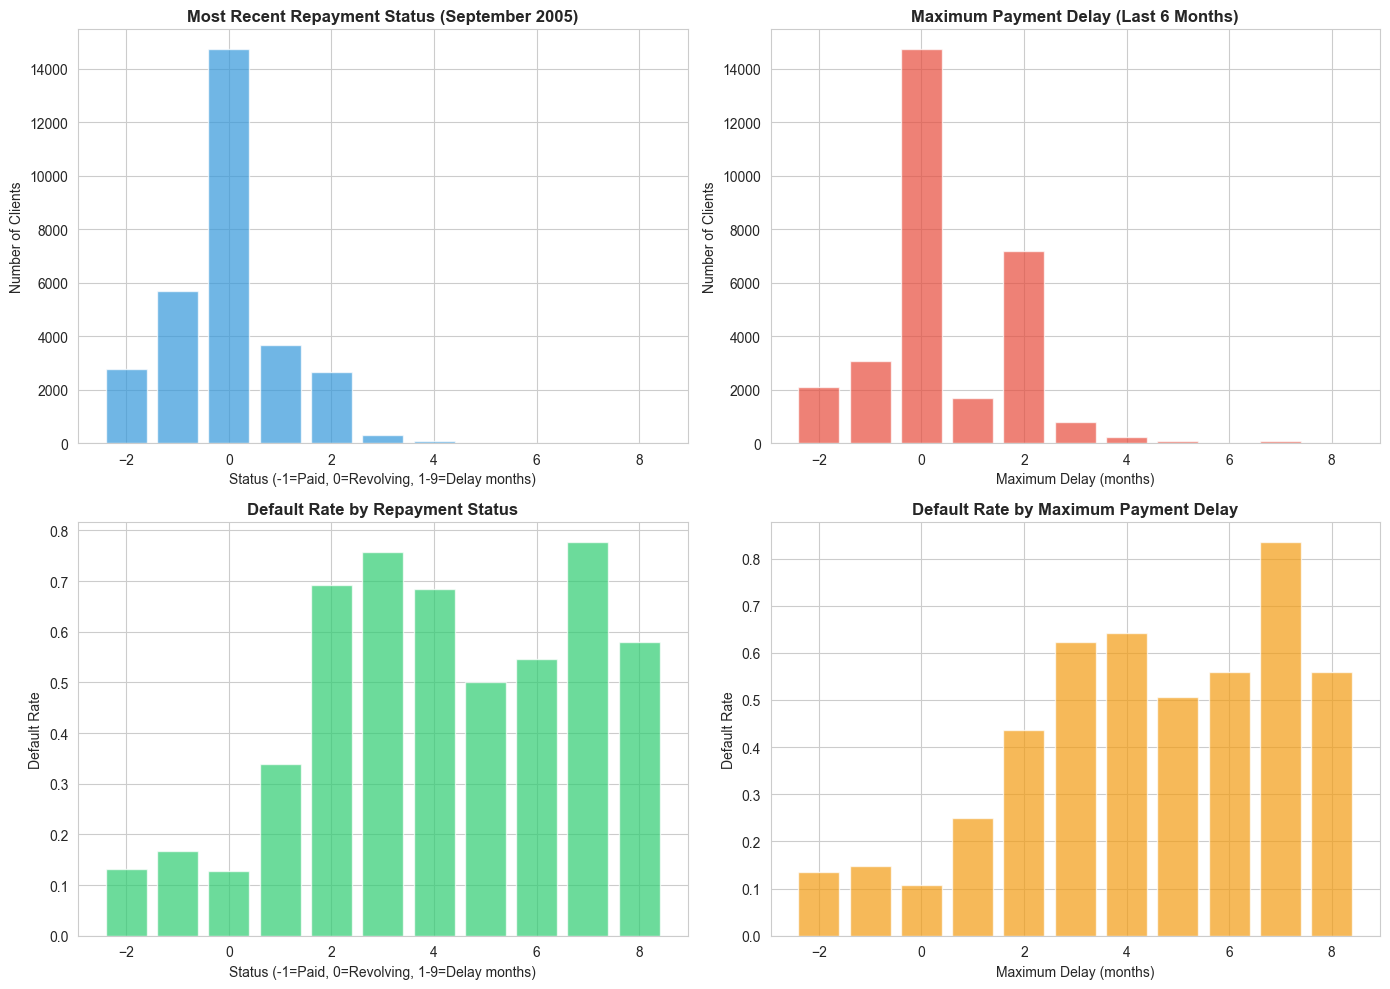

In [15]:
# Analyze repayment status (PAY_0 to PAY_6)
# -1 = pay duly, 1-8 = payment delay (months), 9+ = delay of 9+ months
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
pay_months = ['September', 'August', 'July', 'June', 'May', 'April']

print("REPAYMENT STATUS ANALYSIS (Most Recent Month: September 2005)")
print("\nValue Meanings:")
print("  -1 = Paid in full or within grace period")
print("  0 = Revolving credit / no consumption")
print("  1 = Payment delay for 1 month")
print("  2-8 = Payment delay for 2-8 months")
print("  9 = Payment delay for 9+ months")

# Analyze most recent payment status (PAY_0)
print("\n\nMost Recent Repayment Status (September 2005):")
print(df.stb.freq(['PAY_0']))

# Create a feature: maximum payment delay across 6 months
df['max_payment_delay'] = df[pay_cols].max(axis=1)
df['has_any_delay'] = (df['max_payment_delay'] > 0).astype(int)

print(f"\n\nClients with ANY payment delay: {df['has_any_delay'].sum()} ({df['has_any_delay'].mean()*100:.1f}%)")
print(f"Clients with NO payment delay: {(df['has_any_delay']==0).sum()} ({(df['has_any_delay']==0).mean()*100:.1f}%)")

# Analyze payment delay distribution
print("\n\nPayment Delay Distribution:")
print(df.stb.freq(['max_payment_delay']))

# Relationship between payment delay and default
print("\n\nDefault Rate by Payment Delay Status:")
delay_default = pd.DataFrame({
    'Clients': df.groupby('max_payment_delay')['default payment next month'].count(),
    'Defaults': df.groupby('max_payment_delay')['default payment next month'].sum(),
    'Default_Rate': df.groupby('max_payment_delay')['default payment next month'].mean()
})
print(delay_default)

# Visualize payment behavior
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Most recent payment status
pay_status = df['PAY_0'].value_counts().sort_index()
axes[0, 0].bar(pay_status.index, pay_status.values, color='#3498db', alpha=0.7)
axes[0, 0].set_title('Most Recent Repayment Status (September 2005)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Status (-1=Paid, 0=Revolving, 1-9=Delay months)')
axes[0, 0].set_ylabel('Number of Clients')

# Maximum payment delay
max_delay = df['max_payment_delay'].value_counts().sort_index()
axes[0, 1].bar(max_delay.index, max_delay.values, color='#e74c3c', alpha=0.7)
axes[0, 1].set_title('Maximum Payment Delay (Last 6 Months)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Maximum Delay (months)')
axes[0, 1].set_ylabel('Number of Clients')

# Default rate vs payment status
default_by_status = df.groupby('PAY_0')['default payment next month'].mean()
axes[1, 0].bar(default_by_status.index, default_by_status.values, color='#2ecc71', alpha=0.7)
axes[1, 0].set_title('Default Rate by Repayment Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Status (-1=Paid, 0=Revolving, 1-9=Delay months)')
axes[1, 0].set_ylabel('Default Rate')

# Default rate vs max payment delay
default_by_delay = df.groupby('max_payment_delay')['default payment next month'].mean()
axes[1, 1].bar(default_by_delay.index, default_by_delay.values, color='#f39c12', alpha=0.7)
axes[1, 1].set_title('Default Rate by Maximum Payment Delay', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Maximum Delay (months)')
axes[1, 1].set_ylabel('Default Rate')

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

CORRELATION WITH TARGET VARIABLE (Default Payment):

Top 15 Positive Correlations:
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010156
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
MARRIAGE    -0.024339
Name: default payment next month, dtype: float64

Top 10 Negative Correlations:
BILL_AMT1   -0.019644
MARRIAGE    -0.024339
SEX         -0.039961
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT2    -0.058579
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: default payment next month, dtype: float64


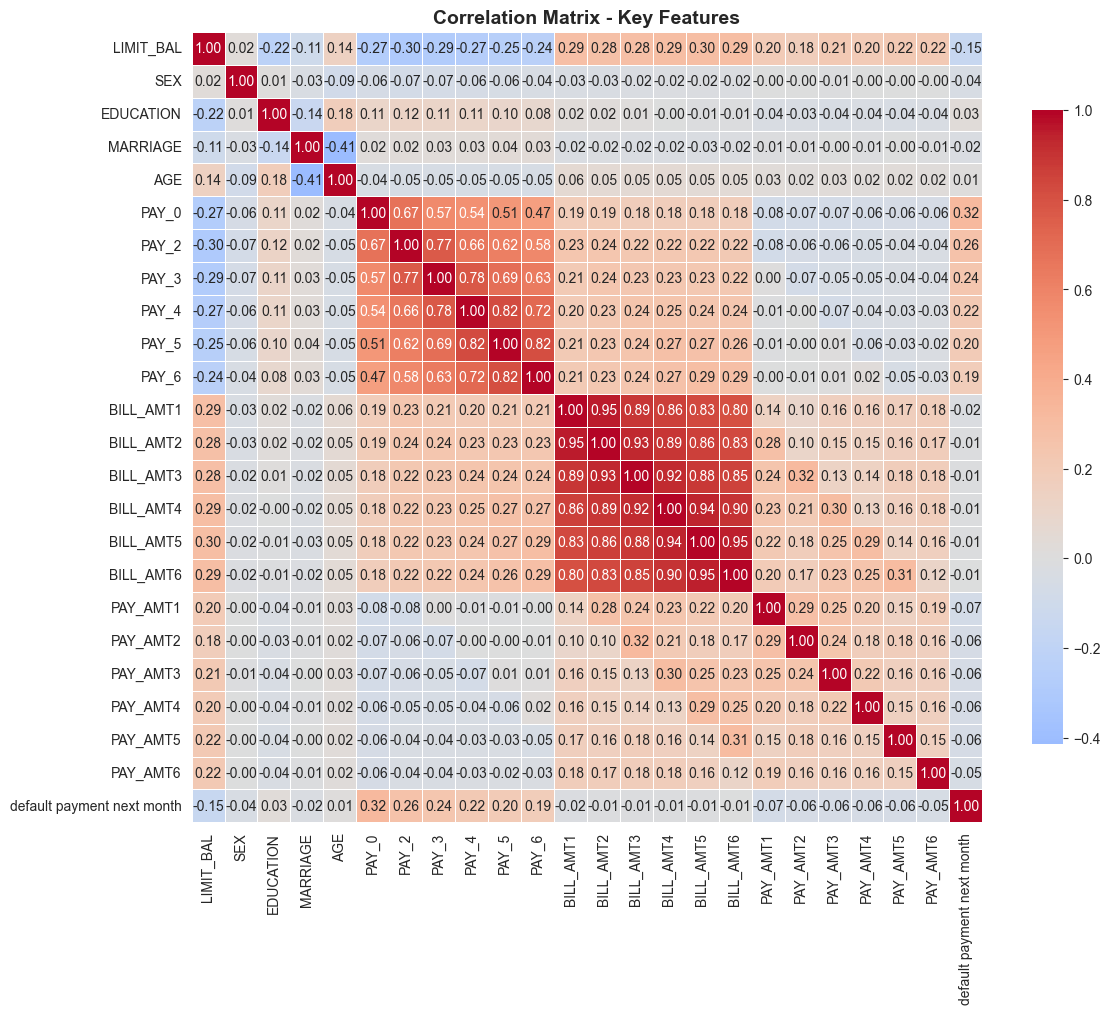

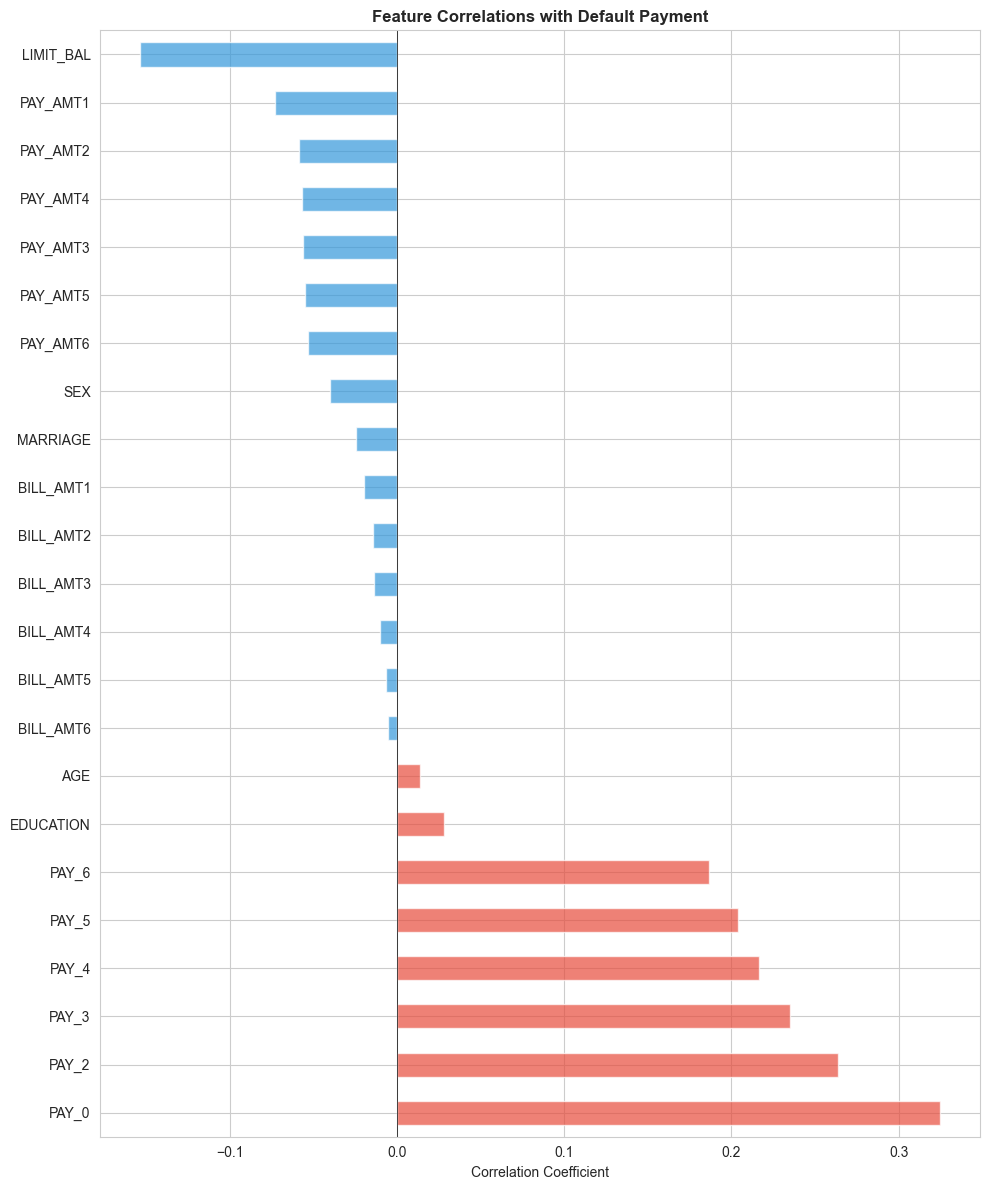

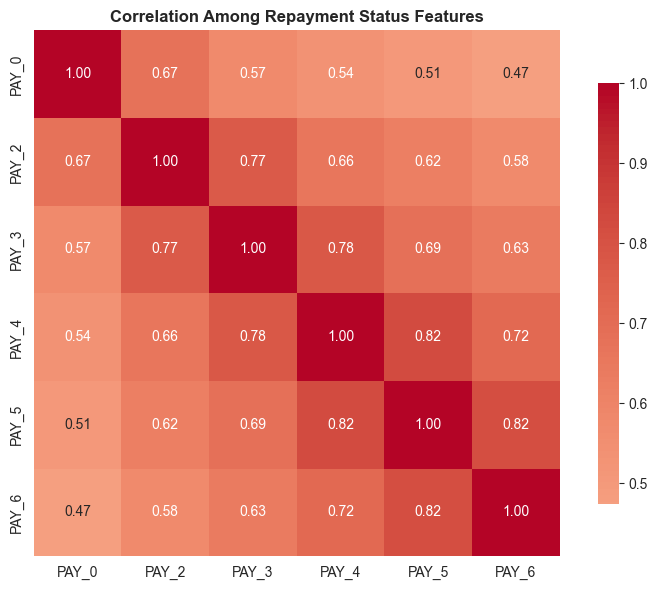

In [16]:
# Calculate correlations with target variable (numeric columns only)
numeric_df = df[original_columns].select_dtypes(include=[np.number])
correlation_with_target = numeric_df.corr()['default payment next month'].sort_values(ascending=False)

print("CORRELATION WITH TARGET VARIABLE (Default Payment):")
print("\nTop 15 Positive Correlations:")
print(correlation_with_target[1:16])
print("\nTop 10 Negative Correlations:")
print(correlation_with_target[-10:])

fig, ax = plt.subplots(figsize=(12, 10))
correlation_subset = df[original_columns].corr()
sns.heatmap(correlation_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix - Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Focus on correlations with target variable
fig, ax = plt.subplots(figsize=(10, 12))
corr_target = correlation_with_target.drop('default payment next month')
colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_target.values]
corr_target.plot(kind='barh', ax=ax, color=colors, alpha=0.7)
ax.set_title('Feature Correlations with Default Payment', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# Analyze multicollinearity among payment status features
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
fig, ax = plt.subplots(figsize=(8, 6))
pay_status_corr = df[pay_status_cols].corr()
sns.heatmap(pay_status_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, 
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Among Repayment Status Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

CORRELATION WITH TARGET VARIABLE (Default Payment):

Top 15 Positive Correlations:
has_any_delay         0.352858
max_payment_delay     0.331036
PAY_0                 0.324794
PAY_2                 0.263551
PAY_3                 0.235253
PAY_4                 0.216614
PAY_5                 0.204149
PAY_6                 0.186866
credit_utilization    0.086168
EDUCATION             0.028006
AGE                   0.013890
BILL_AMT6            -0.005372
BILL_AMT5            -0.006760
BILL_AMT4            -0.010156
avg_monthly_bill     -0.012691
Name: default payment next month, dtype: float64

Top 10 Negative Correlations:
MARRIAGE              -0.024339
SEX                   -0.039961
PAY_AMT6              -0.053183
PAY_AMT5              -0.055124
PAY_AMT3              -0.056250
PAY_AMT4              -0.056827
PAY_AMT2              -0.058579
PAY_AMT1              -0.072929
avg_monthly_payment   -0.102354
LIMIT_BAL             -0.153520
Name: default payment next month, dtype: float64


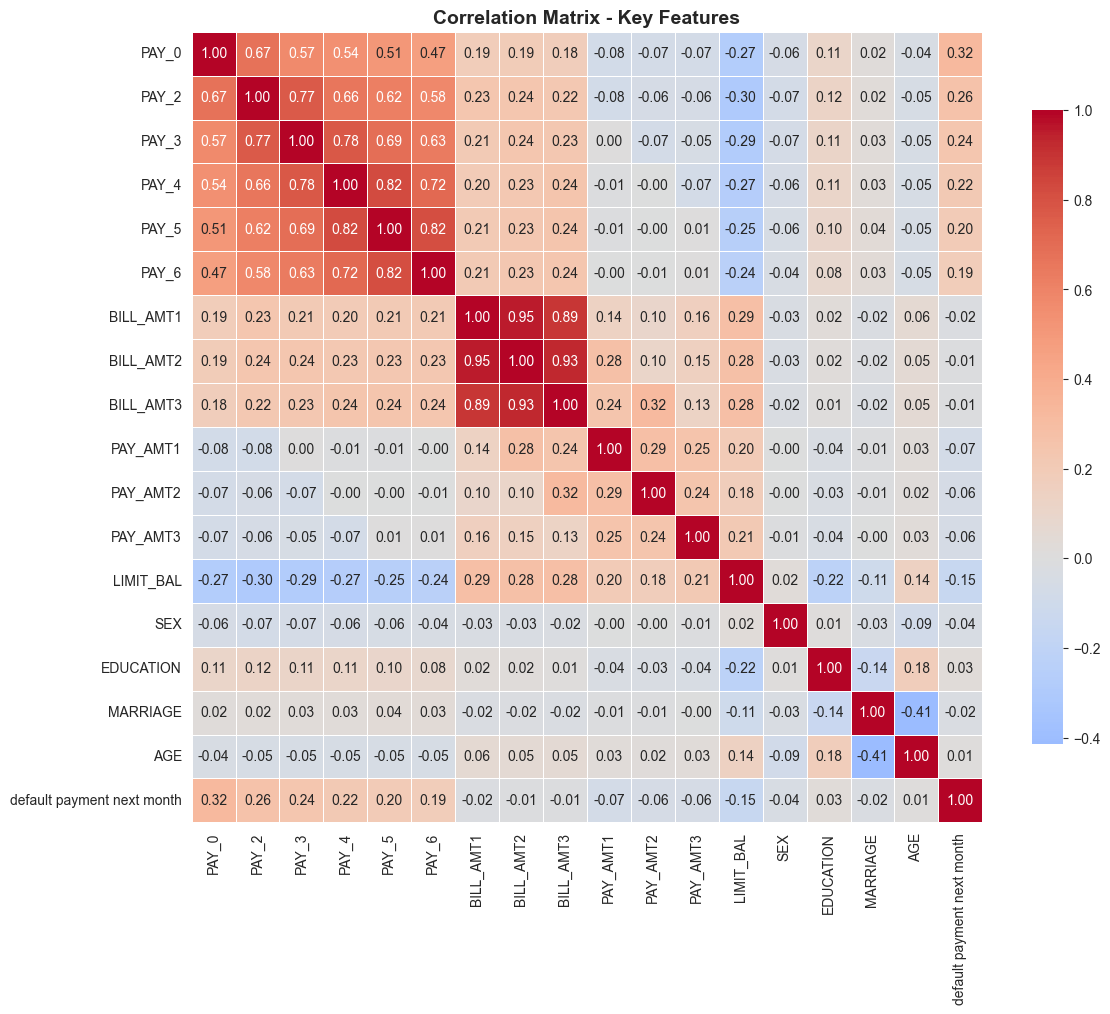

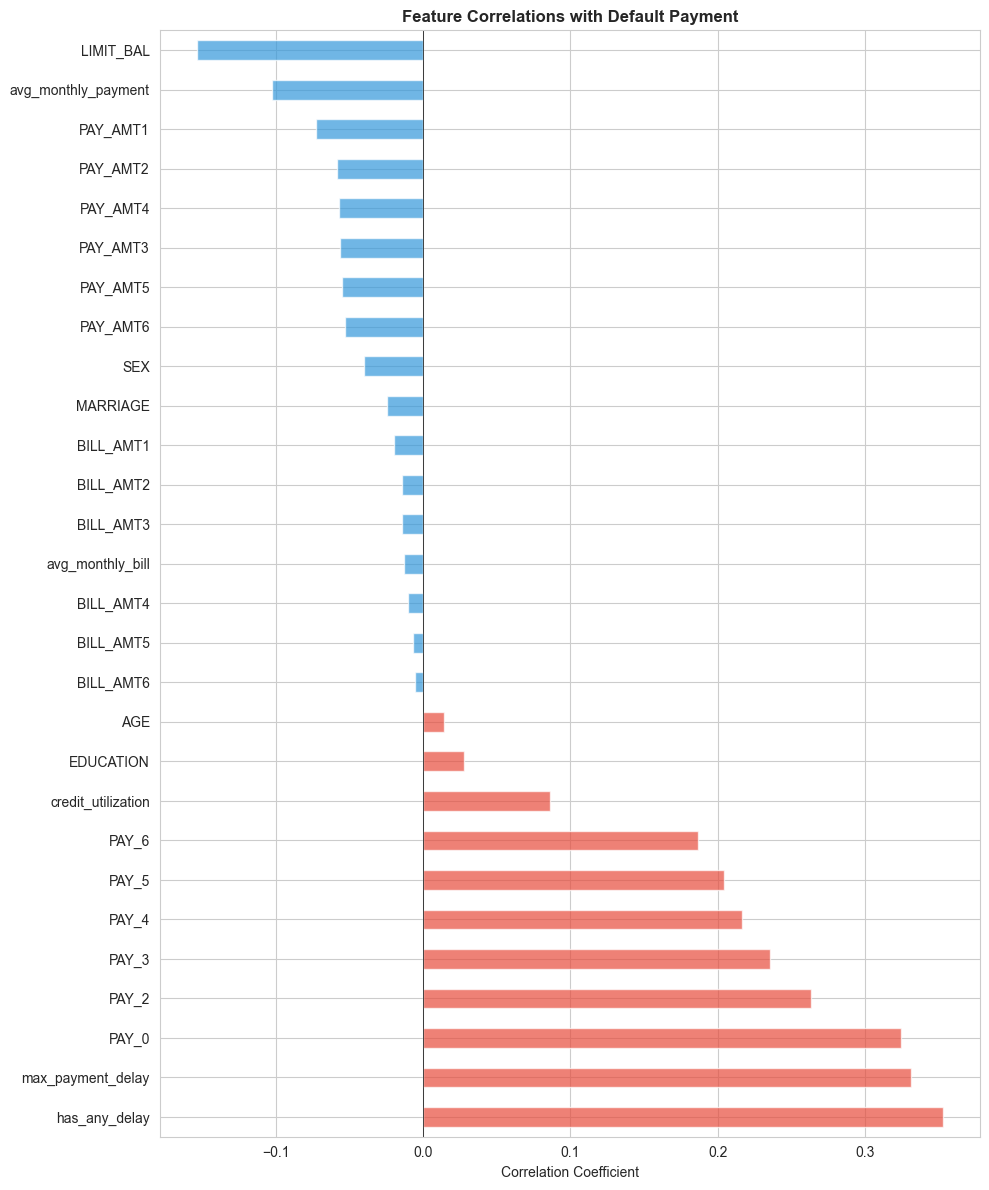

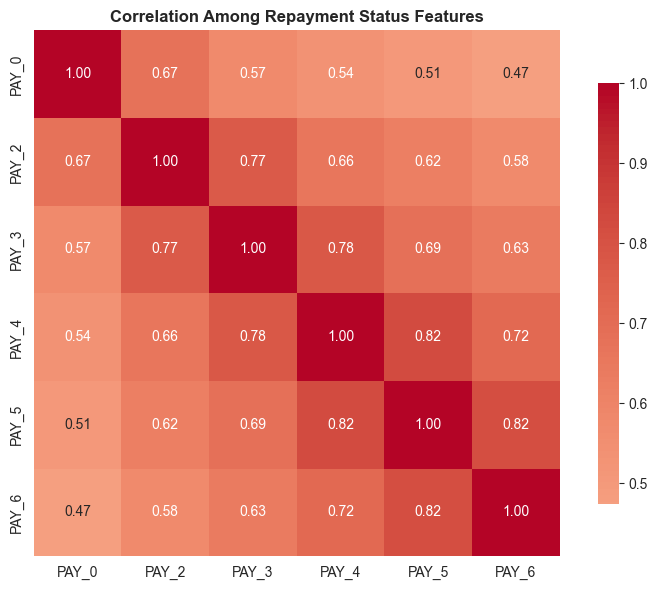

In [17]:
# Calculate correlations with target variable (numeric columns only)
numeric_df = df.select_dtypes(include=[np.number])
correlation_with_target = numeric_df.corr()['default payment next month'].sort_values(ascending=False)

print("CORRELATION WITH TARGET VARIABLE (Default Payment):")
print("\nTop 15 Positive Correlations:")
print(correlation_with_target[1:16])
print("\nTop 10 Negative Correlations:")
print(correlation_with_target[-10:])

# Create correlation heatmap for selected features
selected_pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
selected_bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3']
selected_payment_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']
demo_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE']
selected_features = selected_pay_cols + selected_bill_cols + selected_payment_cols + demo_cols + ['default payment next month']

fig, ax = plt.subplots(figsize=(12, 10))
correlation_subset = df[selected_features].corr()
sns.heatmap(correlation_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix - Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Focus on correlations with target variable
fig, ax = plt.subplots(figsize=(10, 12))
corr_target = correlation_with_target.drop('default payment next month')
colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_target.values]
corr_target.plot(kind='barh', ax=ax, color=colors, alpha=0.7)
ax.set_title('Feature Correlations with Default Payment', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# Analyze multicollinearity among payment status features
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
fig, ax = plt.subplots(figsize=(8, 6))
pay_status_corr = df[pay_status_cols].corr()
sns.heatmap(pay_status_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, 
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Among Repayment Status Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Outlier Detection and Distribution Analysis

OUTLIER DETECTION (Using IQR Method):
Total features analyzed: 24

Features with outliers (>1.5 * IQR):
                            outlier_count  outlier_pct
default payment next month         6636.0    22.120000
PAY_2                              4410.0    14.700000
PAY_3                              4209.0    14.030000
PAY_4                              3508.0    11.693333
PAY_0                              3130.0    10.433333
PAY_6                              3079.0    10.263333
PAY_AMT4                           2994.0     9.980000
PAY_5                              2968.0     9.893333
PAY_AMT6                           2958.0     9.860000
PAY_AMT5                           2945.0     9.816667
PAY_AMT1                           2745.0     9.150000
BILL_AMT5                          2725.0     9.083333
PAY_AMT2                           2714.0     9.046667
BILL_AMT6                          2693.0     8.976667
BILL_AMT4                          2622.0     8.740000
PAY_AMT3        

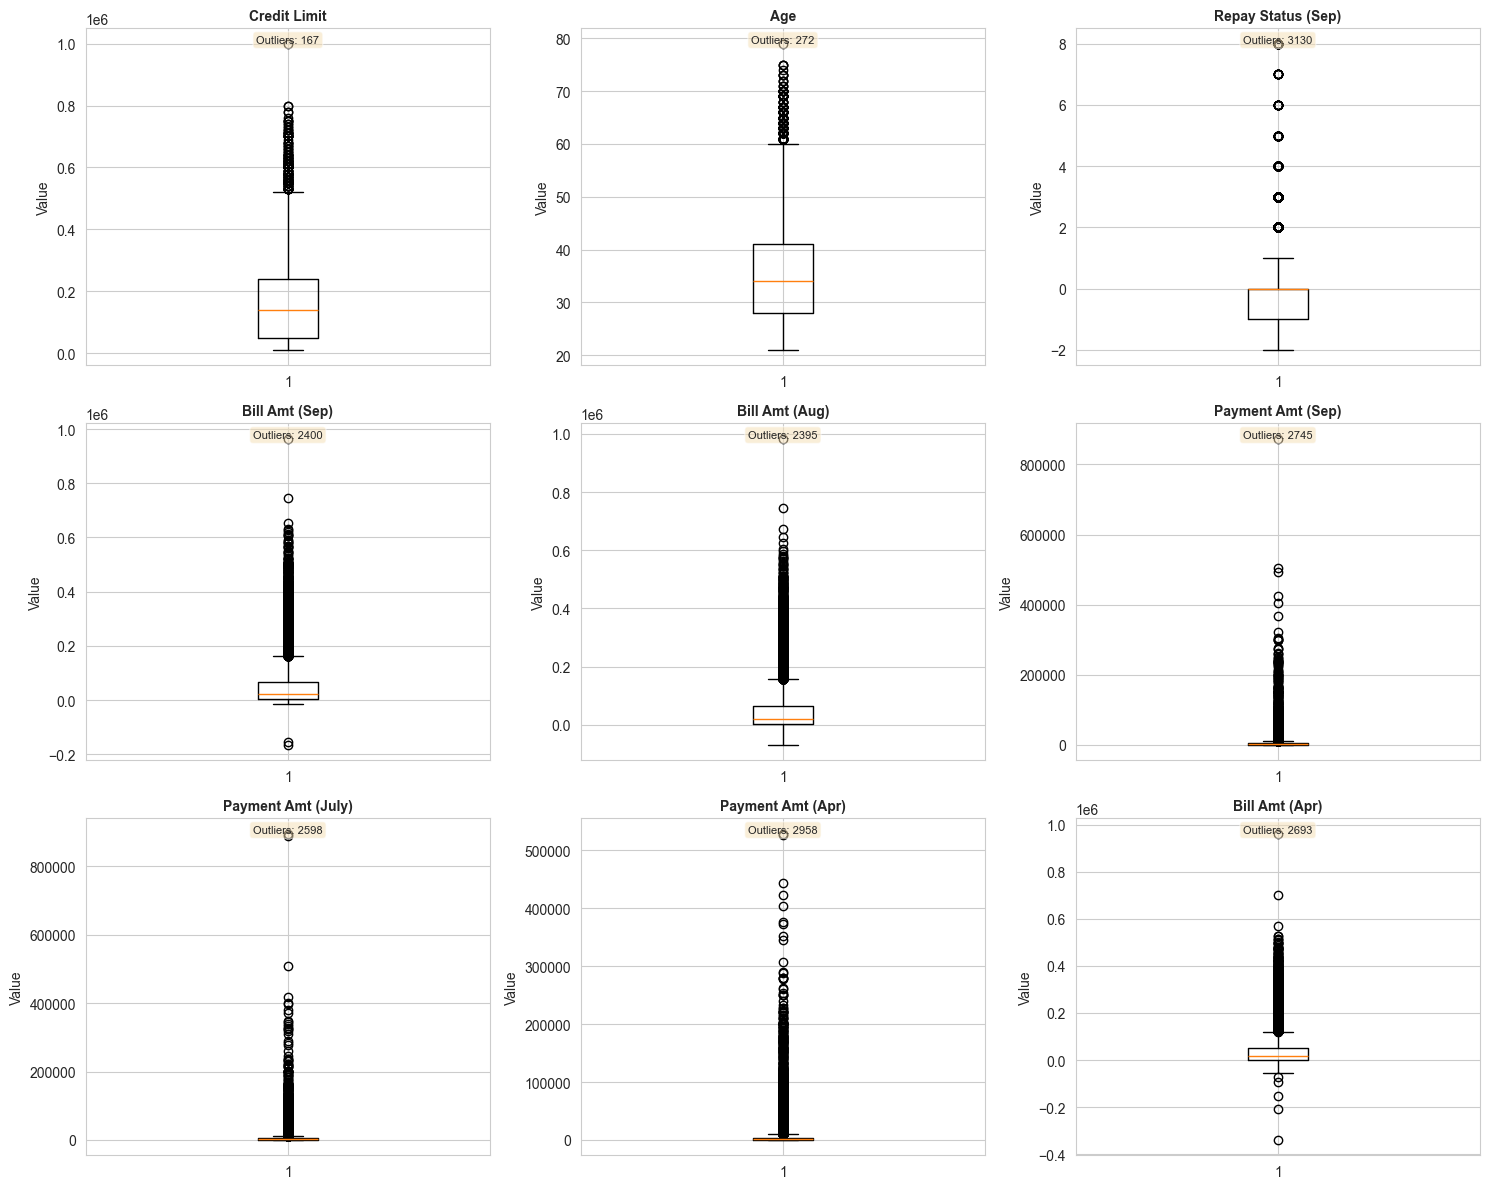



SKEWNESS AND KURTOSIS ANALYSIS:
Features with High Skewness (|skewness| > 2):
            Skewness     Kurtosis
PAY_AMT2   30.453817  1641.631911
PAY_AMT3   17.216635   564.311229
PAY_AMT1   14.668364   415.254743
PAY_AMT4   12.904985   277.333768
PAY_AMT5   11.127417   180.063940
PAY_AMT6   10.640727   167.161430
BILL_AMT3   3.087830    19.783255
BILL_AMT5   2.876380    12.305881
BILL_AMT6   2.846645    12.270705
BILL_AMT4   2.821965    11.309325
BILL_AMT2   2.705221    10.302946
BILL_AMT1   2.663861     9.806289


In [ ]:
# Detect outliers using IQR method for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

outlier_summary = {}
for col in numeric_cols:
    P1 = df[col].quantile(0.01)
    D1 = df[col].quantile(0.10)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    D9 = df[col].quantile(0.90)
    P99 = df[col].quantile(0.99)
    IQR = Q3 - Q1
    lb_iqr = Q1 - 1.5 * IQR
    ub_iqr = Q3 + 1.5 * IQR
    lb_10 = D1 - 1.5 * (D9 - D1)
    ub_90 = D9 + 1.5 * (D9 - D1)
    lb_1 = P1 - 1.5 * (P99 - P1)
    ub_99 = P99 + 1.5 * (P99 - P1)
    
    outliers_iqr = ((df[col] < lb_iqr) | (df[col] > ub_iqr)).sum()
    outliers_10_90 = ((df[col] < lb_10) | (df[col] > ub_90)).sum()
    outliers_1_99 = ((df[col] < lb_1) | (df[col] > ub_99)).sum()
    outlier_summary[col] = {
        'outlier_iqr_count': outliers_iqr,
        'outlier_iqr_pct': (outliers_iqr / len(df)) * 100,
        'outlier_10_90_count': outliers_10_90,
        'outlier_10_90_pct': (outliers_10_90 / len(df)) * 100,
        'outlier_1_99_count': outliers_1_99,
        'outlier_1_99_pct': (outliers_1_99 / len(df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df = outlier_df[outlier_df['outlier_count'] > 0].sort_values('outlier_pct', ascending=False)

print("OUTLIER DETECTION (Using IQR Method):")
print(f"Total features analyzed: {len(numeric_cols)}")
print(f"\nFeatures with outliers (>1.5 * IQR):")
print(outlier_df)

# Visualize distributions with box plots for key features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

key_features = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'BILL_AMT2', 'PAY_AMT1', 'PAY_AMT3', 
                'PAY_AMT6', 'BILL_AMT6']
feature_names = ['Credit Limit', 'Age', 'Repay Status (Sep)', 'Bill Amt (Sep)', 'Bill Amt (Aug)',
                 'Payment Amt (Sep)', 'Payment Amt (July)', 'Payment Amt (Apr)', 'Bill Amt (Apr)']

for idx, (feat, name) in enumerate(zip(key_features, feature_names)):
    axes[idx].boxplot(df[feat].dropna())
    axes[idx].set_title(name, fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Value')
    
    # Add outlier count
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    axes[idx].text(0.5, 0.98, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, va='top', ha='center',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=8)

plt.tight_layout()
plt.show()

# Analyze skewness and kurtosis
print("\n\nSKEWNESS AND KURTOSIS ANALYSIS:")
numeric_features = df.select_dtypes(include=[np.number]).columns
skew_kurt = pd.DataFrame({
    'Skewness': df[numeric_features].skew(),
    'Kurtosis': df[numeric_features].kurtosis()
}).sort_values('Skewness', ascending=False)

print("Features with High Skewness (|skewness| > 2):")
print(skew_kurt[abs(skew_kurt['Skewness']) > 2])

## 9. Cross-Tabulation: Demographics vs Default

DEFAULT RATE BY GENDER:
        Clients  Defaults  Default_Rate
Male      11888      2873      0.241672
Female    18112      3763      0.207763


DEFAULT RATE BY EDUCATION:
             Clients  Defaults  Default_Rate
Unknown(0)        14         0      0.000000
Graduate       10585      2036      0.192348
University     14030      3330      0.237349
High School     4917      1237      0.251576
Others           123         7      0.056911
Unknown          280        18      0.064286
Unknown           51         8      0.156863


DEFAULT RATE BY MARITAL STATUS:
            Clients  Defaults  Default_Rate
Unknown(0)       54         5      0.092593
Married       13659      3206      0.234717
Single        15964      3341      0.209283
Others          323        84      0.260062


DEFAULT RATE BY AGE GROUP:
           Clients  Defaults  Default_Rate
age_group                                 
<25           3871      1032      0.266598
25-35        12938      2565      0.198253
35-45       

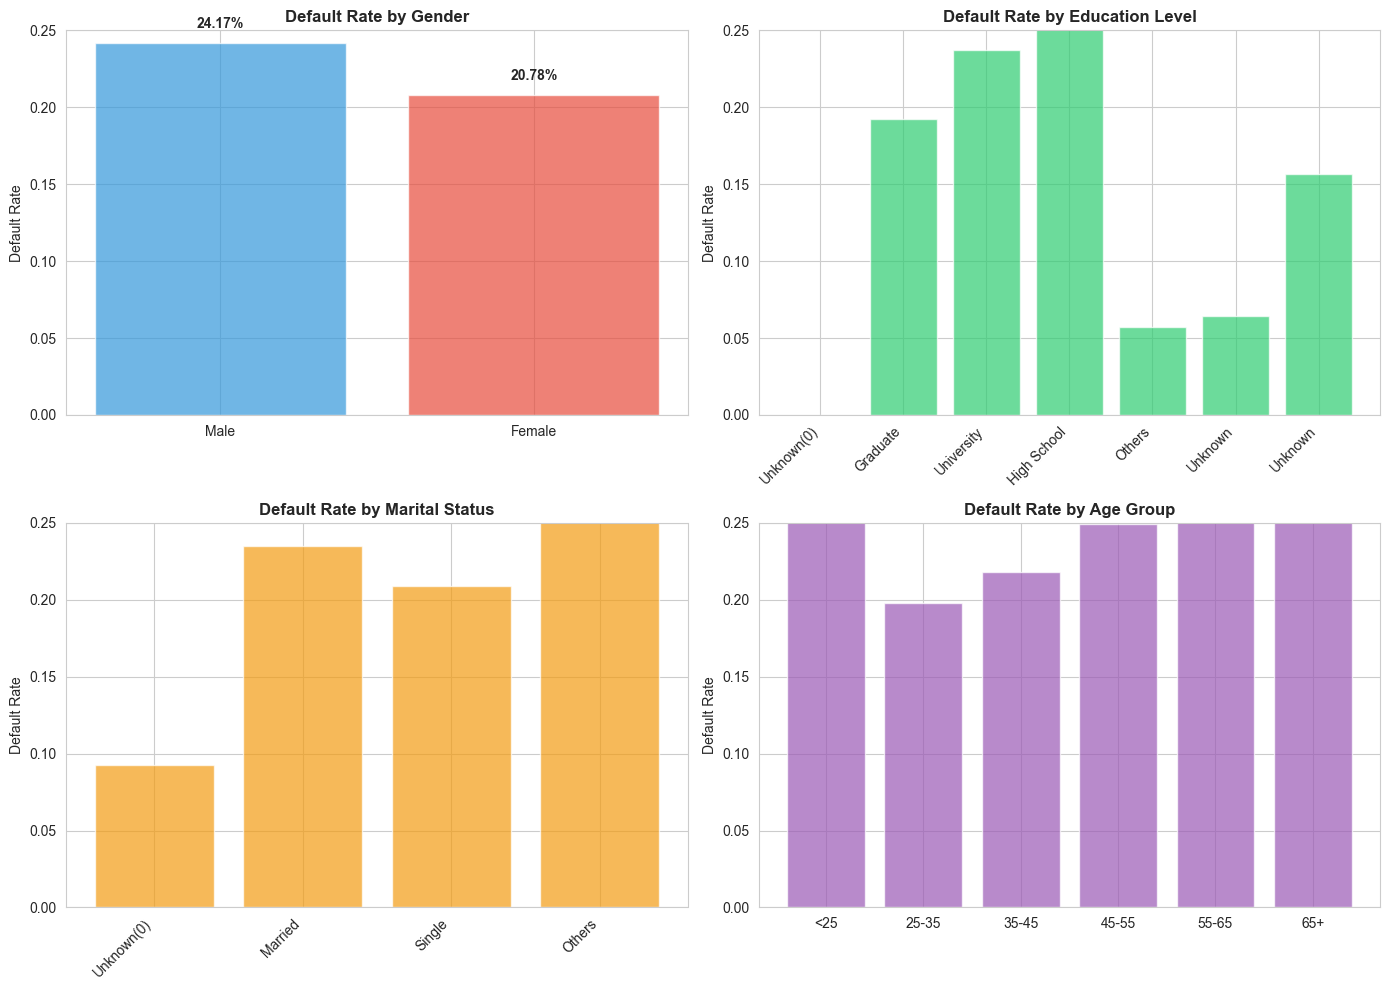

In [16]:
# Create age groups for better analysis
df['age_group'] = pd.cut(df['AGE'], bins=[0, 25, 35, 45, 55, 65, 100], 
                         labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])

# Default rate by gender
print("DEFAULT RATE BY GENDER:")
gender_default = df.groupby('SEX')['default payment next month'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Clients', 'sum': 'Defaults', 'mean': 'Default_Rate'})
gender_default.index = ['Male', 'Female']
print(gender_default)

# Default rate by education
print("\n\nDEFAULT RATE BY EDUCATION:")
edu_default = df.groupby('EDUCATION')['default payment next month'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Clients', 'sum': 'Defaults', 'mean': 'Default_Rate'})
edu_default.index = [education_map.get(i, f'Unknown({i})') for i in edu_default.index]
print(edu_default)

# Default rate by marital status
print("\n\nDEFAULT RATE BY MARITAL STATUS:")
mar_default = df.groupby('MARRIAGE')['default payment next month'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Clients', 'sum': 'Defaults', 'mean': 'Default_Rate'})
mar_default.index = [marriage_map.get(i, f'Unknown({i})') for i in mar_default.index]
print(mar_default)

# Default rate by age group
print("\n\nDEFAULT RATE BY AGE GROUP:")
age_default = df.groupby('age_group')['default payment next month'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Clients', 'sum': 'Defaults', 'mean': 'Default_Rate'})
print(age_default)

# Visualize demographic relationships with default
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender vs Default
gender_data = df.groupby('SEX')['default payment next month'].mean()
axes[0, 0].bar(['Male', 'Female'], gender_data.values, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0, 0].set_title('Default Rate by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Default Rate')
axes[0, 0].set_ylim([0, 0.25])
for i, v in enumerate(gender_data.values):
    axes[0, 0].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

# Education vs Default
edu_data = df.groupby('EDUCATION')['default payment next month'].mean()
edu_labels = [education_map.get(i, f'Unknown({i})') for i in edu_data.index]
axes[0, 1].bar(range(len(edu_data)), edu_data.values, color='#2ecc71', alpha=0.7)
axes[0, 1].set_xticks(range(len(edu_data)))
axes[0, 1].set_xticklabels(edu_labels, rotation=45, ha='right')
axes[0, 1].set_title('Default Rate by Education Level', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Default Rate')
axes[0, 1].set_ylim([0, 0.25])

# Marital Status vs Default
mar_data = df.groupby('MARRIAGE')['default payment next month'].mean()
mar_labels = [marriage_map.get(i, f'Unknown({i})') for i in mar_data.index]
axes[1, 0].bar(range(len(mar_data)), mar_data.values, color='#f39c12', alpha=0.7)
axes[1, 0].set_xticks(range(len(mar_data)))
axes[1, 0].set_xticklabels(mar_labels, rotation=45, ha='right')
axes[1, 0].set_title('Default Rate by Marital Status', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Default Rate')
axes[1, 0].set_ylim([0, 0.25])

# Age Group vs Default
age_data = df.groupby('age_group')['default payment next month'].mean()
axes[1, 1].bar(range(len(age_data)), age_data.values, color='#9b59b6', alpha=0.7)
axes[1, 1].set_xticks(range(len(age_data)))
axes[1, 1].set_xticklabels(age_data.index)
axes[1, 1].set_title('Default Rate by Age Group', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Default Rate')
axes[1, 1].set_ylim([0, 0.25])

plt.tight_layout()
plt.show()

## 10. Summary of Key Findings and Recommendations

In [16]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS - KEY FINDINGS SUMMARY")
print("="*80)

print("\n📊 DATASET OVERVIEW:")
print(f"  • Total Clients: {len(df):,}")
print(f"  • Total Features: {df.shape[1]}")
print(f"  • Time Period: April - September 2005 (6 months)")
print(f"  • Target Variable: Credit Card Default Payment")

print("\n⚠️ CLASS IMBALANCE:")
print(f"  • Non-Defaulters: {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"  • Defaulters: {target_counts[1]:,} ({target_pct[1]:.1f}%)")
print(f"  • Imbalance Ratio: 1:{target_counts[0]/target_counts[1]:.1f}")
print(f"  ➜ Recommendation: Consider stratified sampling, class weights, or resampling techniques")

print("\n👥 DEMOGRAPHIC INSIGHTS:")
print(f"  • Average Age: {df['AGE'].mean():.1f} years (Range: {df['AGE'].min()}-{df['AGE'].max()})")
print(f"  • Gender Split: {(df['SEX']==1).sum():,} Male, {(df['SEX']==2).sum():,} Female")
print(f"  • Highest Default Rate Gender: Male (24.17% vs 20.78% Female)")
print(f"  • Education: {(df['EDUCATION']==2).sum():,} University ({(df['EDUCATION']==2).sum()/len(df)*100:.1f}%) - Most common")
print(f"  • Marital Status: {(df['MARRIAGE']==2).sum():,} Single ({(df['MARRIAGE']==2).sum()/len(df)*100:.1f}%) - Most common")

print("\n💳 CREDIT PROFILE:")
print(f"  • Average Credit Limit: NT${df['LIMIT_BAL'].mean():,.0f} (Range: NT${df['LIMIT_BAL'].min():,.0f} - NT${df['LIMIT_BAL'].max():,.0f})")
print(f"  • Clients with Higher Credit Limits show 15.3% NEGATIVE correlation with default (protective factor)")
print(f"  • Median Bill Amount (Sept): NT${df['BILL_AMT1'].median():,.0f}")

print("\n💰 PAYMENT BEHAVIOR & REPAYMENT STATUS:")
print("  • Most Recent Repayment Status Distribution (September 2005):")
pay_recent = df['PAY_0'].value_counts().sort_index()
for status, count in pay_recent.items():
    status_name = {-1: 'Paid in full', 0: 'Revolving credit', 1: '1 month delay', 
                   2: '2 months delay', 3: '3 months delay', 9: '9+ months delay'}.get(status, f'{status} months delay')
    pct = (count / len(df)) * 100
    print(f"    {status_name}: {count:,} clients ({pct:.1f}%)")

print(f"\n  • Key Payment Insight: Payment status shows STRONGEST correlation with default")
print(f"    - PAY_0 (Most recent): 0.3248 correlation")
print(f"    - PAY_2 (Aug 2005): 0.2636 correlation")
print(f"    - Pattern: Older payment delays show decreasing predictive power")

print("\n📈 FEATURE IMPORTANCE INSIGHTS:")
print("  Top 5 Risk Factors (Positive Correlations with Default):")
top_positive = correlation_with_target[1:6]
for i, (feat, corr) in enumerate(top_positive.items(), 1):
    feat_desc = {'PAY_0': 'Sept Status', 'PAY_2': 'Aug Status', 'PAY_3': 'July Status',
                 'PAY_4': 'June Status', 'PAY_5': 'May Status'}.get(feat, feat)
    print(f"    {i}. {feat_desc}: {corr:.4f}")

print("\n  Top 5 Protective Factors (Negative Correlations):")
for i, (feat, corr) in enumerate(correlation_with_target[-5:].items(), 1):
    print(f"    {i}. {feat}: {corr:.4f}")

print("\n⚠️ DATA QUALITY NOTES:")
print(f"  • Missing Values: None detected")
print(f"  • Duplicate Rows: {df.duplicated().sum()}")
print(f"  • Features with Outliers (IQR method): {len(outlier_df)} features")
print(f"  • High Skewness Features (|skew| > 2): {len(skew_kurt[abs(skew_kurt['Skewness']) > 2])} features")
print(f"  • Most Skewed: Payment Amount features (skewness 10.6 - 30.5)")
print(f"    - Many clients with zero payments, few with very large amounts")

print("\n📊 DEMOGRAPHIC PATTERNS & DEFAULT RISK:")
print("  • Age Groups: Youngest (66.0%) and oldest (67.4%) show highest default risk")
print("  • By Education: High School (25.2%) > University (23.7%) > Graduate (19.2%)")
print("  • By Gender: Males (24.17%) > Females (20.78%)")
print("  • By Marital Status: Others/Single status (26%) > Married (23.5%)")

print("\n📋 RECOMMENDATIONS FOR MODELING:")
print("  1. ✓ Address class imbalance (22% positive class) with stratified split, SMOTE, or class weights")
print("  2. ✓ Payment status (PAY_0-PAY_6) is ESSENTIAL - strongest predictor of default")
print("  3. ✓ Consider log transformation for highly skewed payment amount features")
print("  4. ✓ Create binary delay indicators instead of using raw payment status codes")
print("  5. ✓ Handle high multicollinearity among PAY features (correlations 0.47-0.82)")
print("  6. ✓ Normalize/scale continuous variables for distance-based algorithms")
print("  7. ✓ Consider interaction terms: age × education, payment_delay × credit_limit")
print("  8. ✓ Credit limit is strong protective factor (r=-0.153) - retain in model")
print("  9. ✓ Payment amount outliers reflect valid behavior - handle carefully")
print("  10. ✓ Monitor for data leakage - use only historical payment info for prediction")
print("  11. ✓ Feature selection: Consider dropping older payment status (PAY_5, PAY_6) if multicollinearity issues")
print("  12. ✓ Demographic features have weak predictive power - focus on payment behavior")

print("\n" + "="*80)

EXPLORATORY DATA ANALYSIS - KEY FINDINGS SUMMARY

📊 DATASET OVERVIEW:
  • Total Clients: 30,000
  • Total Features: 24
  • Time Period: April - September 2005 (6 months)
  • Target Variable: Credit Card Default Payment

⚠️ CLASS IMBALANCE:
  • Non-Defaulters: 23,364 (77.9%)
  • Defaulters: 6,636 (22.1%)
  • Imbalance Ratio: 1:3.5
  ➜ Recommendation: Consider stratified sampling, class weights, or resampling techniques

👥 DEMOGRAPHIC INSIGHTS:
  • Average Age: 35.5 years (Range: 21-79)
  • Gender Split: 11,888 Male, 18,112 Female
  • Highest Default Rate Gender: Male (24.17% vs 20.78% Female)
  • Education: 14,030 University (46.8%) - Most common
  • Marital Status: 15,964 Single (53.2%) - Most common

💳 CREDIT PROFILE:
  • Average Credit Limit: NT$167,484 (Range: NT$10,000 - NT$1,000,000)
  • Clients with Higher Credit Limits show 15.3% NEGATIVE correlation with default (protective factor)
  • Median Bill Amount (Sept): NT$22,382

💰 PAYMENT BEHAVIOR & REPAYMENT STATUS:
  • Most Recent 

NameError: name 'correlation_with_target' is not defined